In [1]:
# !pip install -r ../requirements.txt

import sys
sys.path.append('../src')
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import get_cmap
import math

import scipy

import pandas as pd
import numpy as np

In [2]:
#Load the TOT -> ADC calibration for MC

from mcTOTHelper import MCTOTHelper

TOThelper = MCTOTHelper("../calibrations/mc_v8_tot_calibration_averaged.csv")

# Load simulation data 

In [926]:
#As of 2026-09-05, we use the simulation samples labeled version 8
#These have matching ADC and TOT gain to data
#And a working TOT->ADC calibration

#Electron data
#mcdata_0p1GeV = pd.read_csv('../analysis_files/electron_0p1GeV_MC_v8.csv')
#mcdata_0p2GeV = pd.read_csv('../analysis_files/electron_0p2GeV_MC_v8.csv')
#mcdata_0p3GeV = pd.read_csv('../analysis_files/electron_0p3GeV_MC_v8.csv')
#mcdata_0p4GeV = pd.read_csv('../analysis_files/electron_0p4GeV_MC_v8.csv')
#mcdata_0p5GeV = pd.read_csv('../analysis_files/electron_0p5GeV_MC_v8.csv')
mcdata_0p75GeV = pd.read_csv('../analysis_files/electron_0p75GeV_MC_v8.csv')
#mcdata_1GeV = pd.read_csv('../analysis_files/electron_1GeV_MC_v8.csv')
#mcdata_1p5GeV = pd.read_csv('../analysis_files/electron_1p5GeV_MC_v8.csv')
#mcdata_2GeV = pd.read_csv('../analysis_files/electron_2GeV_MC_v8.csv')
#mcdata_2p5GeV = pd.read_csv('../analysis_files/electron_2p5GeV_MC_v8.csv')
#mcdata_3GeV = pd.read_csv('../analysis_files/electron_3GeV_MC_v8.csv')
#mcdata_3p5GeV = pd.read_csv('../analysis_files/electron_3p5GeV_MC_v8.csv')
#mcdata_4GeV = pd.read_csv('../analysis_files/electron_4GeV_MC_v8.csv')
#mcdata_5GeV = pd.read_csv('../analysis_files/electron_5GeV_MC_v8.csv')

#Pion data
#mcdata_0p1GeV_pion = pd.read_csv('../analysis_files/pion_0p1GeV_MC_v8.csv')
#mcdata_0p2GeV_pion = pd.read_csv('../analysis_files/pion_0p2GeV_MC_v8.csv')
#mcdata_0p3GeV_pion = pd.read_csv('../analysis_files/pion_0p3GeV_MC_v8.csv')
#mcdata_0p5GeV_pion = pd.read_csv('../analysis_files/pion_0p5GeV_MC_v8.csv')
#mcdata_1GeV_pion = pd.read_csv('../analysis_files/pion_1GeV_MC_v8.csv')
#mcdata_1p5GeV_pion = pd.read_csv('../analysis_files/pion_1p5GeV_MC_v8.csv')
#mcdata_2GeV_pion = pd.read_csv('../analysis_files/pion_2GeV_MC_v8.csv')
#mcdata_2p5GeV_pion = pd.read_csv('../analysis_files/pion_2p5GeV_MC_v8.csv')
#mcdata_3GeV_pion = pd.read_csv('../analysis_files/pion_3GeV_MC_v8.csv')
#mcdata_3p5GeV_pion = pd.read_csv('../analysis_files/pion_3p5GeV_MC_v8.csv')
#mcdata_4GeV_pion = pd.read_csv('../analysis_files/pion_4GeV_MC_v8.csv')
#mcdata_5GeV_pion = pd.read_csv('../analysis_files/pion_5GeV_MC_v8.csv')



In [837]:
#mcdata_1GeV_0ns = pd.read_csv('../analysis_files/electron_1GeV_MC_v10_0ns.csv')
#mcdata_1GeV_m5ns = pd.read_csv('../analysis_files/electron_1GeV_MC_v10_-5ns.csv')
#mcdata_1GeV_5ns = pd.read_csv('../analysis_files/electron_1GeV_MC_v10_5ns.csv')
#mcdata_1GeV_m10ns = pd.read_csv('../analysis_files/electron_1GeV_MC_v10_-10ns.csv')
#mcdata_1GeV_10ns = pd.read_csv('../analysis_files/electron_1GeV_MC_v10_10ns.csv')


#mcdata_0p3GeV_0ns = pd.read_csv('../analysis_files/electron_0p3GeV_MC_v10_0ns.csv')
#mcdata_0p3GeV_m5ns = pd.read_csv('../analysis_files/electron_0p3GeV_MC_v10_-5ns.csv')
#mcdata_0p3GeV_5ns = pd.read_csv('../analysis_files/electron_0p3GeV_MC_v10_5ns.csv')
#mcdata_0p3GeV_m10ns = pd.read_csv('../analysis_files/electron_0p3GeV_MC_v10_-10ns.csv')
#mcdata_0p3GeV_10ns = pd.read_csv('../analysis_files/electron_0p3GeV_MC_v10_10ns.csv')
#mcdata_0p3GeV_m50ns = pd.read_csv('../analysis_files/electron_0p3GeV_MC_v10_-50.csv')
#mcdata_0p3GeV_50ns = pd.read_csv('../analysis_files/electron_0p3GeV_MC_v10_50.csv')
#mcdata_0p3GeV_m100ns = pd.read_csv('../analysis_files/electron_0p3GeV_MC_v10_-100.csv')
#mcdata_0p3GeV_100ns = pd.read_csv('../analysis_files/electron_0p3GeV_MC_v10_100.csv')

#mcdata_0p3GeV_m12p5ns = pd.read_csv('../analysis_files/electron_0p3GeV_MC_v11_-12p5.csv')
#mcdata_0p3GeV_12p5ns = pd.read_csv('../analysis_files/electron_0p3GeV_MC_v11_12p5.csv')

In [838]:
#mix_4GeV = pd.concat([mcdata_4GeV_pion, mcdata_4GeV])
#mix_1GeV = pd.concat([mcdata_1GeV_pion, mcdata_1GeV])

In [839]:
#brokentot = [(1, 1, 1),(1, 4, 1),(1, 6, 1),(1, 7, 0),(2, 1, 0),(2, 2, 1),(2, 3, 0),(2, 5, 0),(2, 6, 0),(2, 7, 0),(2, 7, 1),(3, 1, 1),(4, 0, 0),(5, 6, 0),(7, 6, 0),(9, 4, 1),(10, 2, 0),(10, 2, 1),(10, 7, 1),(10, 8, 1),(11, 0, 0),(14, 8, 1)]

In [929]:
"""
Process MC data
"""

import random

#Define which simulation dataset to look at, you can also combine multiple ones in this list
datasets = [mcdata_0p75GeV]

#This is actually total energy
amplitudes = []
nHits = []
tot_fraction = []
single_bar_contribution = []
subleading_bar_contribution = []

#Light yield per MIP
#The Poissonian variance in light yield is not simulated in ldmx-sw right now
#So I add it ad-hoc here on the analysis level
pe_per_mip = 60

energy_per_layer = [0 for x in range(0,20)]
energy_per_layer_distribution = [[] for x in range(0,20)]
nevents = 0

for events in datasets:
    for event_i in range(min(events['pf_event']),max(events['pf_event'])):
        event = events.loc[events['pf_event'] == event_i]

        #Number of events you want to process (it's a bit slow)
        if event_i > 2500:
            break
        
        if event_i % 100 == 0:
            print(event_i)
        
        s = 0
        n = 0
        s_tot = 0
        a_max = 0
        a_subleading = 0

        nCentral = 0
        nCentralEven = 0
        nCentralOdd = 0

        firstLayerPositions = []
        hit_energies = []
        sum_back = 0

        energy_per_layer_event = [0 for x in range(0,20)]

            
        for index, subevent in event.iterrows():
            layer = subevent['layer']
            strip = subevent['strip']
    
            end0 = 0
            end1 = 0
    
            isTOT = False
            
            if TOThelper.get_Tc_index(subevent,0) != -1:
                isTOT = True
                #If so, get the TOT value out of the pulse
                rawtot = int(TOThelper.get_TOT(subevent,0))
                end0 = TOThelper.correct_TOT(layer,strip,0,rawtot)
            else:
                end0 = subevent["adc_sum_end"+str(0)]
    
            if TOThelper.get_Tc_index(subevent,1) != -1:
                isTOT = True
                #If so, get the TOT value out of the pulse
                rawtot = int(TOThelper.get_TOT(subevent,1))
                end1 = TOThelper.correct_TOT(layer,strip,1,rawtot)
            else:
                end1 = subevent["adc_sum_end"+str(1)]
    
            #Pedestal subtraction
            end0 -= 800
            end1 -= 800

            if end0 < 0:
                end0 = 0
            if end1 < 0:
                end1 = 0

            np.random.seed(layer+strip)

            gain = (1392-800) #MIP gain in MC, see MC_MIP_Calibration.ipynb
            a = (end0+end1)/2 #Average the two ends
            a = a / gain


            #Simulate light yield            
            a += scipy.stats.norm.rvs()*np.sqrt(a*pe_per_mip)/pe_per_mip

            #Drop small hits
            if a > 0.5:

                if layer < 10 and strip >= 3 and strip <= 8:
                    nCentral += 1
                    if layer % 2 == 0:
                        nCentralEven += 1
                    else:
                        nCentralOdd += 1

                if layer == 1:
                    firstLayerPositions.append(strip)
                if layer >= 16:
                    sum_back += a

                energy_per_layer_event[layer] += a
                
                s += a
                n += 1
                hit_energies.append(a)
                if isTOT:
                    s_tot += a
                if a > a_max:
                    #a_subleading = a_max
                    a_max = a

        upstreamShower = False
        if len(firstLayerPositions) > 0:
            if abs(max(firstLayerPositions)-min(firstLayerPositions)) > 1:
                upstreamShower = True
        #if nCentralEven > 0 and nCentralOdd > 0 and sum_back <= 0.5 and upstreamShower == False:
        #Require hits in the middle (nCentralEvent > 0 and nCentralOdd > 0)
        #and not too many hits in the first layer, to remove upstream showers (upstreamShower == False)
        #For electron events, also require sum_back <= 0.5 to remove pion contamination
        if nCentralEven > 0 and nCentralOdd > 0 and upstreamShower == False:
            amplitudes.append(s)
            nHits.append(n)
            #tot_fraction.append(s_tot/s)
            hit_energies = sorted(hit_energies)
            single_bar_contribution.append(a_max)
            if len(hit_energies) > 1:
                a_subleading = hit_energies[-2]
            subleading_bar_contribution.append(a_subleading)

            for i in range(0,20):
                energy_per_layer[i] += energy_per_layer_event[i]
                energy_per_layer_distribution[i].append(energy_per_layer_event[i])
            nevents += 1


for i in range(1,20):
    energy_per_layer[i] = energy_per_layer[i]/nevents


100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500


'\nfig, axs = plt.subplots(1,3, figsize=(14,5))\nadcbins = np.linspace(500,4000,100)\n\n#sum_adc = [x for x in sum_adc if x > 1200 and x < 2000]\n\naxs[0].hist(sum_adc, bins=adcbins)\naxs[0].set_yscale("log")\naxs[0].set_xlabel("Sum of ADC")\ntotbins = np.linspace(500,4096, 50)\naxs[1].hist(tot, bins=totbins)\naxs[1].set_xlabel("Raw TOT")\n\ncombinedhistbins = np.linspace(500,max(tot_corrected),100)\naxs[2].hist(sum_adc, bins=combinedhistbins, histtype="step", label="ADC")\naxs[2].hist(tot_corrected,bins=combinedhistbins, label="Corrected TOT")\naxs[2].set_yscale("log")\naxs[2].set_xlabel("Sum of ADC")\naxs[2].legend()\n\naxs[0].set_title("Layer " + str(layer) + " Strip " + str(strip) + " End " + str(end))\nplt.show()7.621923075200204\n'

In [360]:
#SiPM saturation correction

sipmcorrectionfile = open("SiPMSaturationCorrection.csv")

sipmcorr_x = []
sipmcorr_y = []

for line in sipmcorrectionfile:
    s = line.split(",")
    if s[0] == '#MIPEequivalents':
        continue
    sipmcorr_x.append(float(s[0]))
    sipmcorr_y.append(float(s[1][:-1]))

Number of events to be processed
51616
Average MC:
20.23792356917467
Standard error MC:
0.08006791443360525
Std dev MC:
3.9945785415020456
Standard error(sigma)
0.05662794203551614
Std dev/average MC:
0.19738084926787527
Standard error on resolution MC:
0.0029050356307730708
Average data:
116.50977961201914
Standard error data:
0.06439766184566988
Std dev data:
14.368906428998269
Standard error(sigma)
0.045536480708073694
Std dev/average data:
0.12332789982821299
Standard error on resolution data:
0.0003967381800620361
49786
[0.0, 0.0, 0.0006696129637069774, 0.003481987411276282, 0.021829382616847463, 0.07365742600776752, 0.1033882415963573, 0.07124681933842239, 0.040310700415160036, 0.014329717423329315, 0.0037498325967590734, 0.0006696129637069774, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 6.695322647598387e-06, 1.3390645295196

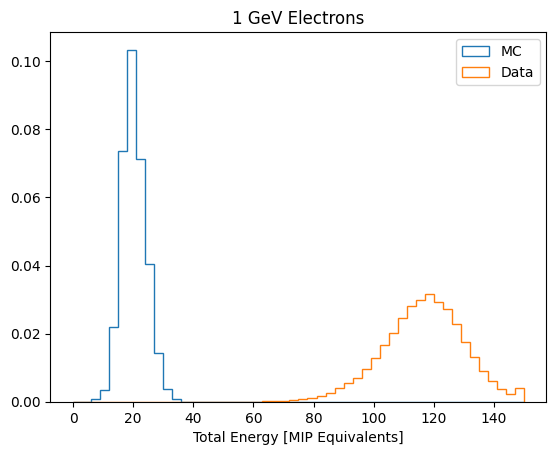

In [931]:
"""
Load data json files (made using Lei's calibrations), and produce comparison plots
"""

import json
from scipy.optimize import curve_fit

"""
TB data files

0.3 GeV electrons: electron_0p3GeV.json
0.4 GeV electrons: electron_0p4GeV.json
0.5 GeV electrons: electron_0p5GeV.json
1 GeV electrons:
4 GeV electrons: tbdata/electron_4GeV.json

0.1 GeV pions: tbdata/run291_0p1GeV.json
0.2 GeV pions: tbdata/run291_0p2GeV.json
0.3 GeV pions: tbdata/run293.json
1 GeV pions: tbdata/run285.json
2 GeV pions: tbdata/run286.json
3 GeV pions: tbdata/pion_3GeV.json
4 GeV pions: tbdata/run288.json
"""

#Load data
filename = "tbdata/electron_4GeV.json"
f = open(filename, "r")
dataunsorted = json.load(f)
eventnumbers = set([x[-1] for x in dataunsorted])

#Number of events to process
max_event_number = 1000000

dataunsorted = [x for x in dataunsorted if x[-1] <= max_event_number]
datasorted = sorted(dataunsorted,key = (lambda x: x[-1]))

energy_per_layer_data = [0 for x in range(0,20)]
energy_per_layer_data_distributions = [[] for x in range(0,20)]
nevents_data = 0

#Group hits into events, to speed up analysis
event = []
data = []
currentevent = -1
for i,hit in enumerate(datasorted):
    if hit[-1] != currentevent:
        if currentevent != -1:
            data.append(event)
        event = []
        currentevent = hit[-1]
    event.append(hit)
    if i == len(datasorted)-1:
        data.append(event)

energy_sums = []
leading_hits = []
leading_hits_isTOT = []
subleading_hits = []
nHitsData = []
nHitsInTOTData = []
nHitsCentralData = []

print("Number of events to be processed")
print(len(data))
for event in data:
    #Total energy
    s = 0
    #Number of hits
    n = 0
    nCentral = 0
    nCentralEven = 0
    nCentralOdd = 0
    firstLayerPositions = []

    a_max = 0
    a_max_is_TOT = False
    a_second = 0
    
    sum_back = 0

    numberOfTots = 0
    
    energy_per_layer_event = [0 for x in range(0,20)]
    
    for hit in sorted(event,key = (lambda x: x[0])):
        layer = hit[-3]
        strip = hit[-2]
        
        e = hit[0]*np.interp(hit[0],sipmcorr_x,sipmcorr_y)


        if e > 0.5:
            if hit[-5] > 0 or hit[-4] > 0:
                numberOfTots += 1

        #Hit energy threshold
        if e > 0.5:
            s += e
            if e > a_max:
                a_second = a_max
                a_max = e
                #a_max_is_TOT = numberOfTots
            n += 1
            if layer < 10 and strip >= 3 and strip <= 8:
                nCentral += 1
                if layer % 2 == 0:
                    nCentralEven += 1
                else:
                    nCentralOdd += 1
            if layer == 1:
                firstLayerPositions.append(strip)
            if layer >= 16:
                sum_back += e
            energy_per_layer_event[layer] += e
    #Checks so there isn't too much activity in the first layer
    #To remove upstream showers, and pile-up
    upstreamShower = False
    if len(firstLayerPositions) > 0:
        if abs(max(firstLayerPositions)-min(firstLayerPositions)) > 1:
            upstreamShower = True
            #print(firstLayerPositions)
    #if nCentralEven > 0 and nCentralOdd > 0 and sum_back <= 0.5 and upstreamShower == False:
    """
    Remove events with no hits in central bars (require nCentralEven and nCentralOdd >0)
    Remove events with too many hits in the first layer (indiciative of something showering
    upstream, upstreamShower == False)

    In electron events, require sum_back <= 0.5, to remove events with energy in the back 
    layers. Those events are probably pions, from what we see in event displays
    """
    if nCentralEven > 0 and nCentralOdd > 0 and upstreamShower == False:
        energy_sums.append(s)
        nHitsData.append(n)
        nHitsCentralData.append(nCentral)
        leading_hits.append(a_max)
        leading_hits_isTOT.append(a_max_is_TOT)
        subleading_hits.append(a_second)
        for i in range(0,20):
            energy_per_layer_data[i] += energy_per_layer_event[i]
            energy_per_layer_data_distributions[i].append(energy_per_layer_event[i])
        nevents_data += 1
        nHitsInTOTData.append(numberOfTots)

    #if s < 1:
    #    print(event)

for i in range(1,20):
    energy_per_layer_data[i] = energy_per_layer_data[i]/nevents_data

"""
Print results
"""

print("Average MC:")
print(np.average(amplitudes))
print("Standard error MC:")
print(np.sqrt(np.var(amplitudes)/nevents))
print("Std dev MC:")
print(np.sqrt(np.var(amplitudes)))
print("Standard error(sigma)")
print(np.sqrt(np.var(amplitudes))/np.sqrt(2*(nevents-1)))
print("Std dev/average MC:")
print(np.sqrt(np.var(amplitudes))/np.average(amplitudes))
print("Standard error on resolution MC:")
#print(np.sqrt(np.var(amplitudes))/np.average(amplitudes)*np.sqrt(np.sqrt(
#    (np.var(amplitudes))/np.average(amplitudes))**2/nevents+1/(2*(nevents-1))))
print(np.sqrt(np.var(amplitudes))/np.average(amplitudes)*np.sqrt(
    (np.sqrt(np.var(amplitudes))/np.average(amplitudes))**2/nevents+
    1/(2*(nevents-1))))

#Data
print("Average data:")
print(np.average(energy_sums))
print("Standard error data:")
print(np.sqrt(np.var(energy_sums)/nevents_data))
print("Std dev data:")
print(np.sqrt(np.var(energy_sums)))
print("Standard error(sigma)")
print(np.sqrt(np.var(energy_sums))/np.sqrt(2*(nevents_data-1)))
print("Std dev/average data:")
print(np.sqrt(np.var(energy_sums))/np.average(energy_sums))
cv = np.sqrt(np.var(energy_sums))/np.average(energy_sums)
print("Standard error on resolution data:")
print(cv*np.sqrt(cv**2/nevents_data+1/(2*(nevents_data-1))))

#print(nevents_data)

bins = np.linspace(0,150,51)
#bins = np.linspace(0,200,51)
bin_centres = [(bins[i]+bins[i+1])/2 for i in range(0,len(bins)-1)]


# Define model function to be used to fit to the data above:
def gauss(x, *p):
    A, mu, sigma = p
    return A*np.exp(-(x-mu)**2/(2.*sigma**2))

# p0 is the initial guess for the fitting coefficients (A, mu and sigma above)
p0 = [0.05, 20, 10.]


"""
Total energy histogram
"""

counts,_,_ = plt.hist(np.clip(amplitudes,bins[0],bins[-1]),bins=bins,histtype="step",density=True,label="MC")
#print(counts.tolist())

#Make Gaussian fits if you wish (mostly makes sense for electrons)
"""
coeff, var_matrix = curve_fit(gauss, bin_centres, counts, p0=p0)
print("MC Gaussian fit ratio:")
print(coeff[2]/coeff[1])
hist_fit = gauss(bin_centres, *coeff)
plt.plot(bin_centres, hist_fit, color="blue")
"""

counts,_,_ = plt.hist(np.clip(energy_sums,bins[0],bins[-1]), bins=bins, histtype="step",density=True,label="Data")
#print(counts.tolist())

#Make Gaussian fits if you wish (mostly makes sense for electrons)
"""
coeff, var_matrix = curve_fit(gauss, bin_centres, counts, p0=p0)
print("Data Gaussian fit mu:")
print(coeff[1])
print("Data Gaussian fit ratio:")
print(coeff[2]/coeff[1])
hist_fit = gauss(bin_centres, *coeff)
plt.plot(bin_centres, hist_fit, color="red")
"""

plt.legend()
plt.title("1 GeV Electrons")
plt.xlabel("Total Energy [MIP Equivalents]")
#plt.yscale("log")
#plt.ylim(1e-5,0.1)
plt.savefig("plots/datamccomparisons/energysum_"+filename.split("/")[1].split(".")[0])
plt.show()


(array([2.86762295e-01, 3.56683321e-01, 8.60997435e-02, 4.66367917e-02,
        2.72195983e-02, 1.66159797e-02, 1.35551413e-02, 1.50035738e-02,
        1.86793127e-02, 1.61103948e-02, 1.31725365e-02, 1.11092035e-02,
        9.18251510e-03, 7.95271397e-03, 6.95520861e-03, 5.71174302e-03,
        5.13783583e-03, 4.61858646e-03, 4.18132384e-03, 3.10183174e-03,
        3.00618054e-03, 2.07699746e-03, 2.04966855e-03, 1.79004387e-03,
        1.79004387e-03, 2.14531975e-03, 1.22980113e-03, 1.09315656e-03,
        7.78874049e-04, 8.47196334e-04, 6.01236108e-04, 4.64591538e-04,
        4.50927081e-04, 5.60242737e-04, 3.82604796e-04, 4.37262624e-04,
        2.59624683e-04, 3.14282511e-04, 2.32295769e-04]),
 array([ 0.        ,  1.02564103,  2.05128205,  3.07692308,  4.1025641 ,
         5.12820513,  6.15384615,  7.17948718,  8.20512821,  9.23076923,
        10.25641026, 11.28205128, 12.30769231, 13.33333333, 14.35897436,
        15.38461538, 16.41025641, 17.43589744, 18.46153846, 19.48717949,
  

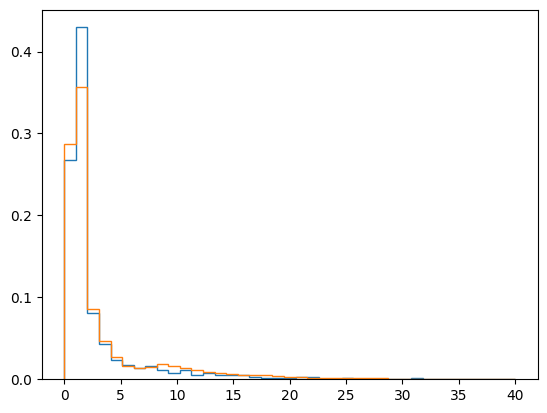

In [746]:
bins = np.linspace(0,40,40)
plt.hist(energy_per_layer_distribution[2],histtype="step",label="MC",density=True,bins=bins)
plt.hist(energy_per_layer_data_distributions[2],histtype="step",label="Data",density=True,bins=bins)

[0.0, 0.0, 0.0, 0.0, 0.0, 0.00045392646391284613, 0.0, 0.00045392646391284613, 0.0, 0.0, 0.0009078529278256923, 0.0009078529278256923, 0.003631411711302769, 0.0027235587834770767, 0.005447117566954153, 0.004539264639128461, 0.013617793917385384, 0.013163867453472538, 0.018157058556513846, 0.07035860190649115, 0.055832955061280075, 0.04675442578302315, 0.04312301407172038, 0.05401724920562869, 0.064911484339537, 0.05901044030867, 0.05991829323649569, 0.06672719019518839, 0.05901044030867, 0.06173399909214707, 0.06082614616432138, 0.048116205174761686, 0.0463004993191103, 0.03949160236041761, 0.02315024965955515, 0.024965955515206535, 0.01270994098955969, 0.013617793917385384, 0.007716749886518384, 0.017703132092601]
[0.0, 0.0, 7.65239749613554e-05, 6.121917996908431e-05, 0.00012243835993816862, 0.00024487671987633724, 0.000581582209706301, 0.0009642020845130779, 0.0014080411392889392, 0.0022038904788870355, 0.003275226128346011, 0.0046067432926735945, 0.00667289061663019, 0.008983914660

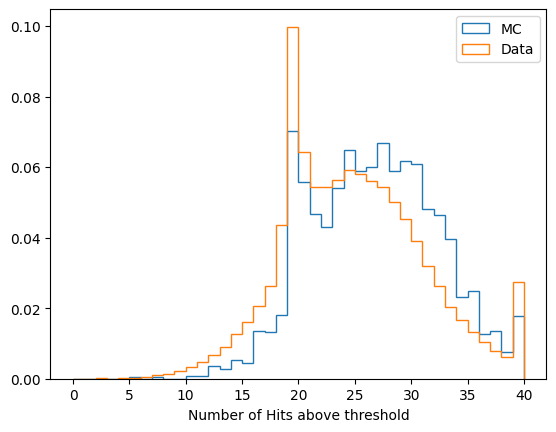

In [826]:
"""
Number of hits histogram
"""

nHitsBins = np.linspace(0,40,41)

#Remember to clip values to minimum and maximum bin, to create overflow bins at each end
counts,_,_ = plt.hist(np.clip(nHits,0,max(nHitsBins)),bins=nHitsBins,histtype="step",density=True,label="MC")
#Print out bin entries for use in plots later
print(counts.tolist())
counts,_,_ = plt.hist(np.clip(nHitsData,0,max(nHitsBins)), bins=nHitsBins, histtype="step",density=True,label="Data")
#Print out bin entries for use in plots later
print(counts.tolist())
plt.xlabel("Number of Hits above threshold")
plt.legend()
#plt.savefig("plots/datamccomparisons/nhits_"+filename.split("/")[1].split(".")[0])
plt.show()

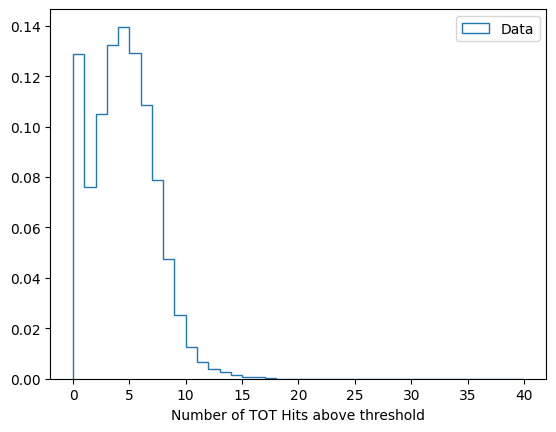

In [793]:
nHitsBins = np.linspace(0,40,41)

#counts,_,_ = plt.hist(nHits,bins=nHitsBins,histtype="step",density=True,label="MC")
#print(counts.tolist())
counts,_,_ = plt.hist(nHitsInTOTData, bins=nHitsBins, histtype="step",density=True,label="Data")
#print(counts.tolist())
#plt.title("3 GeV Pions")
plt.xlabel("Number of TOT Hits above threshold")
plt.legend()
#plt.savefig("plots/datamccomparisons/nhits_"+filename.split("/")[1].split(".")[0])
plt.show()

(array([[3.024e+03, 1.205e+03, 9.300e+01, 2.300e+01, 0.000e+00, 0.000e+00,
         0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00],
        [2.394e+03, 5.413e+03, 1.563e+03, 8.750e+02, 4.000e+01, 6.000e+00,
         0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00],
        [9.290e+02, 9.566e+03, 4.967e+03, 4.270e+03, 4.290e+02, 1.470e+02,
         8.000e+00, 0.000e+00, 1.000e+00, 0.000e+00],
        [2.330e+02, 5.944e+03, 5.294e+03, 6.561e+03, 9.760e+02, 4.490e+02,
         2.900e+01, 0.000e+00, 0.000e+00, 1.000e+00],
        [0.000e+00, 1.145e+03, 2.065e+03, 4.002e+03, 8.450e+02, 4.840e+02,
         3.300e+01, 6.000e+00, 0.000e+00, 1.000e+00],
        [0.000e+00, 7.200e+01, 3.230e+02, 1.062e+03, 3.630e+02, 2.870e+02,
         3.200e+01, 0.000e+00, 4.000e+00, 0.000e+00],
        [0.000e+00, 1.000e+00, 1.400e+01, 1.250e+02, 7.200e+01, 8.000e+01,
         2.700e+01, 3.000e+00, 2.000e+00, 1.000e+00],
        [0.000e+00, 0.000e+00, 1.000e+00, 1.200e+01, 6.000e+00, 1.800e+01,
         6.000e+00, 3.

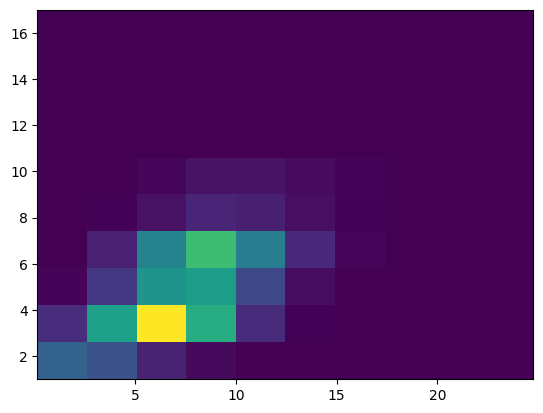

In [251]:
plt.hist2d(energy_sums,nHitsData)

[0.0, 0.013617793917385384, 0.04085338175215615, 0.029051293690422152, 0.018157058556513846, 0.025873808443032227, 0.03313663186563777, 0.04176123467998184, 0.053109396277803, 0.06536541080344985, 0.07762142532909669, 0.0699046754425783, 0.0699046754425783, 0.06627326373127554, 0.05946436677258284, 0.053109396277803, 0.032682705401724924, 0.04221516114389469, 0.03495233772128915, 0.028597367226509306, 0.024058102587380843, 0.015433499773036768, 0.019064911484339538, 0.013163867453472538, 0.013617793917385384, 0.010894235133908307, 0.01044030866999546, 0.024965955515206535, 0.01270994098955969, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.02182870973177494, 0.052817818354498246, 0.028630076132412186, 0.013388275302155297, 0.015211164044668433, 0.024540065256353303, 0.03203075933273081, 0.04793125105313951, 0.06678819258283421, 0.07761829628835343, 0.07823103200012255, 0.0655780395520902, 0.05557512905745929, 0.04865121551446822, 0.04643004855930516, 0.04200303304177326

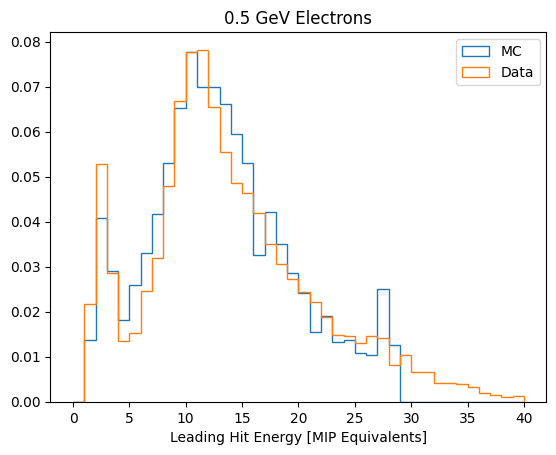

In [817]:
"""
Leading hit histogram
"""

leadingBarBins = np.linspace(0,40,41)

counts,_,_ = plt.hist(single_bar_contribution,bins=leadingBarBins,histtype="step",density=True,label="MC")
#Print out bin entries for use in plots later
print(counts.tolist())
counts,_,_ = plt.hist(leading_hits, bins=leadingBarBins, histtype="step",density=True,label="Data")
#Print out bin entries for use in plots later
print(counts.tolist())
plt.title("0.5 GeV Electrons")
plt.xlabel("Leading Hit Energy [MIP Equivalents]")
plt.legend()
plt.savefig("plots/datamccomparisons/leadinghit_"+filename.split("/")[1].split(".")[0])
plt.show()

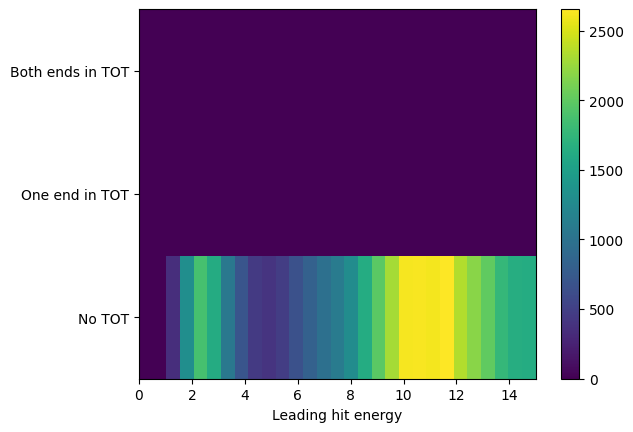

In [824]:
#Plot of leading hit energy vs how many sides were in TOT-mode in the bar
plt.hist2d(leading_hits, leading_hits_isTOT,bins=[np.linspace(0,15,30),[0,1,2,3]])
plt.xlabel("Leading hit energy")
plt.yticks([0.5,1.5,2.5],["No TOT", "One end in TOT", "Both ends in TOT"])
plt.colorbar()

[0.0, 0.0, 0.05560599182932365, 0.050416099258586776, 0.051157512482977736, 0.03707066121954911, 0.04670903313663188, 0.04151914056589497, 0.0682100166439703, 0.0645029505220154, 0.08971100015130892, 0.10379785141473744, 0.10453926463912841, 0.10083219851717366, 0.11417763655621102, 0.09119382660009087, 0.08822817370252695, 0.08748676047813571, 0.0771069753366622, 0.06227871084884238, 0.04670903313663191, 0.05338175215615076, 0.03558783477076707, 0.028173702526857348, 0.02965652897563931, 0.016311090936601574, 0.017052504160992604, 0.009638371917082776, 0.01334543803903769, 0.012604024814646633, 0.008155545468300811, 0.005931305795127862, 0.005931305795127862, 0.004448479346345896, 0.005189892570736849, 0.002224239673172948, 0.0007414132243909828, 0.002224239673172948, 0.0, 0.0007414132243909785, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0007414132243909785, 0.0, 0.0, 0.0]
[2.5051124744376278e-05, 0.0032566462167689164, 0.07214723926380368, 0.07322443762781186, 0.04852402862985683, 0.0271053169734151

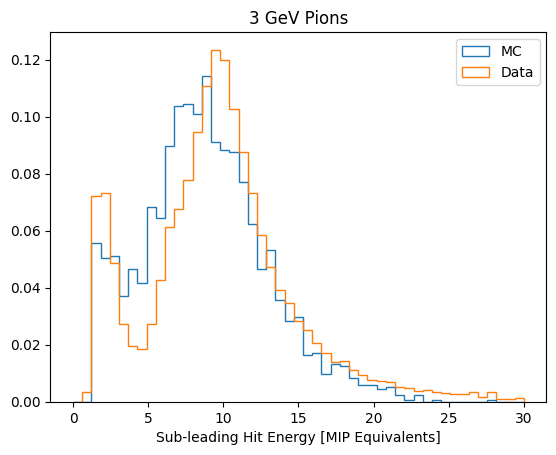

In [819]:
"""
Subleading hit histogram
"""

leadingBarBins = np.linspace(0,30,50)

counts,_,_ = plt.hist(subleading_bar_contribution,bins=leadingBarBins,histtype="step",density=True,label="MC")
#Print out bin entries for use in plots later
print(counts.tolist())
counts,_,_ = plt.hist(subleading_hits, bins=leadingBarBins, histtype="step",density=True,label="Data")
#Print out bin entries for use in plots later
print(counts.tolist())#'#MIPEequivalents'
plt.title("3 GeV Pions")
plt.xlabel("Sub-leading Hit Energy [MIP Equivalents]")
plt.legend()
plt.savefig("plots/datamccomparisons/subleadinghit_"+filename.split("/")[1].split(".")[0])
plt.show()

[0.0, 2.172183629502594, 3.5250523778255305, 4.533999617989166, 5.237890571782375, 5.501893977371933, 5.7673108321589694, 5.733147362542831, 5.315877551894035, 4.926275369031681, 4.7797925949828, 4.654789815670735, 4.05865718126089, 3.728698685590945, 3.514273504503554, 3.0637394796299176, 2.813817446296135, 2.5093523797763537, 2.3887584302292457, 2.130586381933297]
[0.0, 2.773547707745884, 4.5044352956740665, 4.959849005857135, 5.485239230325767, 6.3926282138917845, 6.631925481066061, 5.274872949560823, 4.731370994394551, 5.869489455146337, 5.490420257532853, 4.609807713163377, 3.4044327460200163, 3.0222709743456035, 2.9278339685112176, 3.5862401465228197, 2.9833889512833345, 2.5755092889276043, 2.2817915322631483, 1.5428650310479335]


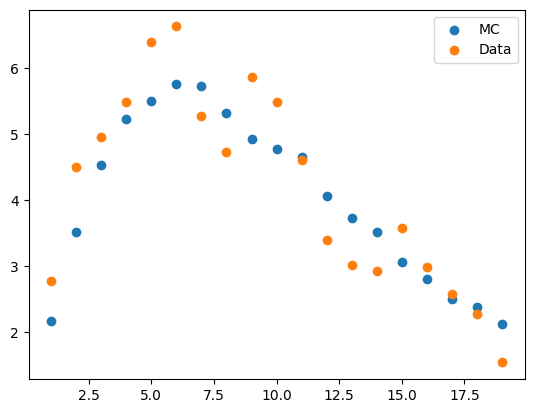

In [823]:
"""
Longitudinal shower profiles
"""

#Average energy deposited in each layer
print([float(x) for x in energy_per_layer]) # MC
print([float(x) for x in energy_per_layer_data]) # Data
plt.scatter([i for i in range(1,20)], energy_per_layer[1:], label="MC")
plt.scatter([i for i in range(1,20)], energy_per_layer_data[1:], label="Data")
plt.legend()
#plt.xticks([i for i in range(1,20)])

[146.37463395   7.7053629    3.02848062]


ValueError: x and y must have the same length.

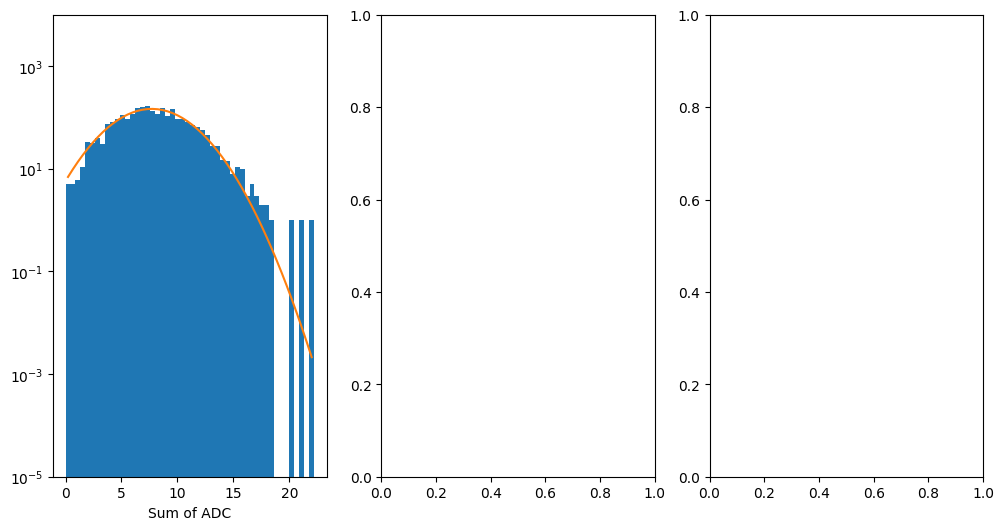

In [115]:
"""
import matplotlib as mpl

import numpy
from scipy.optimize import curve_fit

fig, axs = plt.subplots(1,3, figsize=(12,6))

counts,bins,_ = axs[0].hist(amplitudes, bins=50)
axs[0].set_yscale("log")

bin_centres = [(bins[i]+bins[i+1])/2 for i in range(0,len(bins)-1)]

# Define model function to be used to fit to the data above:
def gauss(x, *p):
    A, mu, sigma = p
    return A*numpy.exp(-(x-mu)**2/(2.*sigma**2))

# p0 is the initial guess for the fitting coefficients (A, mu and sigma above)
p0 = [100., 50., 10.]

coeff, var_matrix = curve_fit(gauss, bin_centres, counts, p0=p0)
print(coeff)

# Get the fitted curve
hist_fit = gauss(bin_centres, *coeff)

axs[0].set_ylim(1e-5,1e4)
axs[0].plot(bin_centres, hist_fit, label='Test data')
axs[0].set_xlabel("Sum of ADC")

axs[1].hist2d(amplitudes,tot_fraction,bins=50,norm=mpl.colors.LogNorm(),)
axs[1].set_ylabel("Fraction in TOT mode")
axs[1].set_xlabel("Sum of ADC")
axs[2].hist2d(amplitudes,single_bar_contribution,bins=50,norm=mpl.colors.LogNorm(),)
axs[2].set_ylabel("Fraction carried by most energetic bar")
axs[2].set_xlabel("Sum of ADC")
plt.show()
"""

In [ ]:
x_e = [400,500, 4000]
y_e = [10.81654066, 13.5600727, 112.23859495]

def linear(x,a,b):
    return x*a+b

popt, pcov = curve_fit(linear, x_e, y_e)

print(linear(3000,*popt))

x_e_data = [300,400,4000]
y_e_data = [7, 9.9, 161]

poptdata, pcovdata = curve_fit(linear, x_e_data, y_e_data)

print(linear(3000,*poptdata))

#x_pi = [500,1000,3000,4000]
#y_pi = [43298.84608481, 49378.96818456 , 73552.80067021, 87146.68591823]

#print("e/h at 3 GeV: " + str(linear(3000,*popt)/y_pi[-2]))

xrange = np.linspace(300,4000,100)

#print(y_e[-1]/y_pi[-1])

plt.plot(x_e,y_e, marker="*", label="MC")
plt.plot(x_e_data,y_e_data, marker="*", label="Data")
#plt.plot(xrange,[linear(x,*popt) for x in xrange], linestyle="--")
#plt.plot(x_pi,y_pi, marker="*")
plt.xlabel("Energy")
plt.ylabel("Total MIP Equivalents")
plt.title("Monte-Carlo vs Data")
plt.legend()
plt.show()

In [33]:
#Here I load v9 samples (with the TOT threshold really high) to derive correction factors for ADC saturation

#mcdata_0p1GeV_TOT = pd.read_csv('../analysis_files/electron_0p1GeV_MC_v8.csv')
#mcdata_0p1GeV_noTOT = pd.read_csv('../analysis_files/electron_0p1GeV_MC_v9.csv')
mcdata_0p3GeV_TOT = pd.read_csv('../analysis_files/electron_0p3GeV_MC_v8.csv')
mcdata_0p3GeV_noTOT = pd.read_csv('../analysis_files/electron_0p3GeV_MC_v9.csv')
#mcdata_0p4GeV_TOT = pd.read_csv('../analysis_files/electron_0p4GeV_MC_v8.csv')
#mcdata_0p4GeV_noTOT = pd.read_csv('../analysis_files/electron_0p4GeV_MC_v9.csv')
#mcdata_0p5GeV_TOT = pd.read_csv('../analysis_files/electron_0.5GeV_MC_v8.csv')
#mcdata_0p5GeV_noTOT = pd.read_csv('../analysis_files/electron_0p5GeV_MC_v9.csv')
#mcdata_1GeV_TOT = pd.read_csv('../analysis_files/electron_1GeV_MC_v8.csv')
#mcdata_1GeV_noTOT = pd.read_csv('../analysis_files/electron_1GeV_MC_v9.csv')
#mcdata_1p5GeV_TOT = pd.read_csv('../analysis_files/electron_1p5GeV_MC_v8.csv')
#mcdata_1p5GeV_noTOT = pd.read_csv('../analysis_files/electron_1p5GeV_MC_v9.csv')
#mcdata_2GeV_TOT = pd.read_csv('../analysis_files/electron_2GeV_MC_v8.csv')
#mcdata_2GeV_noTOT = pd.read_csv('../analysis_files/electron_2GeV_MC_v9.csv')
#mcdata_2p5GeV_TOT = pd.read_csv('../analysis_files/electron_2p5GeV_MC_v8.csv')
#mcdata_2p5GeV_noTOT = pd.read_csv('../analysis_files/electron_2p5GeV_MC_v9.csv')
#mcdata_3GeV_TOT = pd.read_csv('../analysis_files/electron_3GeV_MC_v8.csv')
#mcdata_3GeV_noTOT = pd.read_csv('../analysis_files/electron_3GeV_MC_v9.csv')
#mcdata_3p5GeV_TOT = pd.read_csv('../analysis_files/electron_3p5GeV_MC_v8.csv')
#mcdata_3p5GeV_noTOT = pd.read_csv('../analysis_files/electron_3p5GeV_MC_v9.csv')
#mcdata_4GeV_TOT = pd.read_csv('../analysis_files/electron_4GeV_MC_v8.csv')
#mcdata_4GeV_noTOT = pd.read_csv('../analysis_files/electron_4GeV_MC_v9.csv')
#mcdata_5GeV_TOT = pd.read_csv('../analysis_files/electron_5GeV_MC_v8.csv')
#mcdata_5GeV_noTOT = pd.read_csv('../analysis_files/electron_5GeV_MC_v9.csv')




100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000
8100
8200
8300
8400
8500
8600
8700
8800
8900
9000
9100
9200
9300
9400
9500
9600
9700
9800
9900
10000
10100
10200
10300
10400
10500
10600
10700
10800
10900
11000
11100
11200
11300
11400
11500
11600
11700
11800
11900
12000
12100
12200
12300
12400
12500
12600
12700
12800
12900
13000
13100
13200
13300
13400
13500
13600
13700
13800
13900
14000
14100
14200
14300
14400
14500
14600
14700
14800
14900
15000
15100
15200
15300
15400
15500
15600
15700
15800
15900
16000
16100
16200
16300
16400
16500
16600
16700
16800
16900
17000
17100
17200
17300
17400
17500
17600
17700
17800
17900
18000
18100
18200
18300
18400
1850

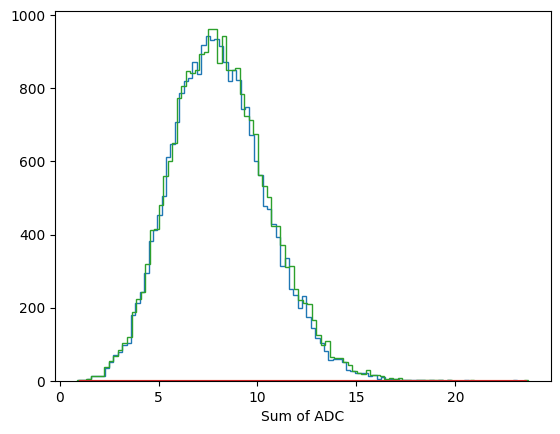

In [37]:
import random
import numpy
from scipy.optimize import curve_fit

#datasets = [mcdata_4GeV_TOT, mcdata_4GeV_noTOT]
datasets = [mcdata_0p3GeV_TOT, mcdata_0p3GeV_noTOT]

for ds in datasets:
    amplitudes = []
    tot_fraction = []
    single_bar_contribution = []
    
    for event_i in range(min(ds['pf_event']),max(ds['pf_event'])):
        event = ds.loc[ds['pf_event'] == event_i]

        if event_i > 25000:
            break
        
        if event_i % 100 == 0:
            print(event_i)
        
        s = 0
        s_tot = 0
        a_max = 0
    
        for index, subevent in event.iterrows():
            layer = subevent['layer']
            strip = subevent['strip']
    
            end0 = 0
            end1 = 0
    
            isTOT = False
            
            if TOThelper.get_Tc_index(subevent,0) != -1:
                isTOT = True
                rawtot = int(TOThelper.get_TOT(subevent,0))
                end0 = TOThelper.correct_TOT(layer,strip,0,rawtot)
            else:
                end0 = subevent["adc_sum_end"+str(0)]
    
            if TOThelper.get_Tc_index(subevent,1) != -1:
                isTOT = True
                rawtot = int(TOThelper.get_TOT(subevent,1))
                end1 = TOThelper.correct_TOT(layer,strip,1,rawtot)
            else:
                end1 = subevent["adc_sum_end"+str(1)]
    
            #Pedestal reduction
            end0 -= 800
            end1 -= 800
    
            a = (end0+end1)/2

            a = a / (1392-800)

            #if a >= 4:
            #    a = 4
            
            if a > 0.05:
                #if True:
                s += a
                if isTOT:
                    s_tot += a
                if a > a_max:
                    a_max = a
            
        amplitudes.append(s)
        #tot_fraction.append(s_tot/s)
        #single_bar_contribution.append(a_max/s)
                

    counts,bins,_ = plt.hist(amplitudes, bins=100, histtype="step")
    #plt.yscale("log")
    
    bin_centres = [(bins[i]+bins[i+1])/2 for i in range(0,len(bins)-1)]
    
    # Define model function to be used to fit to the data above:
    def gauss(x, *p):
        A, mu, sigma = p
        return A*numpy.exp(-(x-mu)**2/(2.*sigma**2))
    
    # p0 is the initial guess for the fitting coefficients (A, mu and sigma above)
    p0 = [1500., 80., 7.]
    
    coeff, var_matrix = curve_fit(gauss, bin_centres, counts, p0=p0)
    print(coeff)
    
    # Get the fitted curve
    hist_fit = gauss(bin_centres, *coeff)
    
    #plt.ylim(1e-5,1e4)
    plt.plot(bin_centres, hist_fit, label='Test data')
    plt.xlabel("Sum of ADC")
    #plt.show()
    
    #plt.hist2d(amplitudes,tot_fraction,bins=50)
    #plt.show()
    #plt.hist2d(amplitudes,single_bar_contribution,bins=50)
    #plt.show()

plt.show()

# Plots

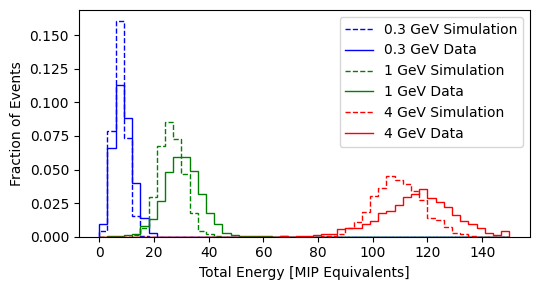

In [511]:
fig, ax = plt.subplots(1,1,figsize=(5.5,3))

#Low energy electrons
#bins = np.linspace(0,50,51)

bins = np.linspace(0,150,51)

sum_electron_0p3GeV_mc = [0.00389948006932409, 0.07900057770075102, 0.16074523396880416, 0.07322357019064125, 0.015742345465049105, 0.0007221259387637204, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sum_electron_0p3GeV_data = [0.009231213039088417, 0.06620510601471224, 0.11308235972883311, 0.08812923698254724, 0.0398096062310688, 0.013991057262368383, 0.0025962786672436176, 0.0, 0.0, 0.0001442377037357565, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0001442377037357565, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

sum_electron_0p5GeV_mc = [0.0, 0.0, 0.00040535062829347385, 0.0, 0.002026753141467369, 0.0032428050263477908, 0.009728415079043373, 0.033238751520064856, 0.0510741791649777, 0.0806647750304013, 0.10620186461289015, 0.1147142278070531, 0.12241588974462911, 0.1284961491690312, 0.10174300770166193, 0.08309687880016214, 0.0620186461289015, 0.038508309687880014, 0.029995946493717066, 0.01580867450344548, 0.008512363194162952, 0.0036481556546412645, 0.002837454398054317, 0.0008107012565869477, 0.0, 0.0008107012565869477, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sum_electron_0p5GeV_data = [0.0, 0.0006740815638692282, 0.002696326255476913, 0.004044489383215369, 0.00910010111223458, 0.012133468149646108, 0.01887428378833839, 0.027637344118638354, 0.03875968992248062, 0.043478260869565216, 0.056959892146949784, 0.07280080889787664, 0.07650825749915739, 0.08088978766430738, 0.07718233906302663, 0.08459723626558814, 0.07785642062689585, 0.0694304010785305, 0.06336366700370745, 0.05325244354566903, 0.03640040444893832, 0.032018874283788336, 0.021233569261880688, 0.012133468149646108, 0.01314459049544995, 0.005392652510953826, 0.003707448601280755, 0.0013481631277384564, 0.0013481631277384564, 0.0006740815638692282, 0.0, 0.0010111223458038423, 0.0, 0.0, 0.0003370407819346141, 0.0, 0.0, 0.0, 0.0, 0.0003370407819346141, 0.0, 0.0003370407819346141, 0.0, 0.0, 0.0003370407819346141, 0.0, 0.0, 0.0, 0.0, 0.0]

ax.stairs(sum_electron_0p3GeV_mc, bins, color="blue", linestyle="--", label="0.3 GeV Simulation")
ax.stairs(sum_electron_0p3GeV_data, bins, color="blue", label="0.3 GeV Data")

#ax.stairs(sum_electron_0p5GeV_mc, bins, color="orange", linestyle="--", label="0.5 GeV Simulation")
#ax.stairs(sum_electron_0p5GeV_data, bins, color="orange",label="0.5 GeV Data")

#plt.show()
#bins = np.linspace(0,150,51)

sum_electron_1GeV_mc = [0.0, 0.0, 0.0, 0.00013478905512872354, 0.0016174686615446825, 0.0063350855910500065, 0.02924922496293301, 0.06739452756436178, 0.08518668284135328, 0.07292087882463945, 0.04650222401940962, 0.01752257716673406, 0.00417846070899043, 0.0020218358269308533, 0.0002695781102574471, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sum_electron_1GeV_data = [0.0, 0.0004577497024626934, 0.0005492996429552321, 0.0013732491073880802, 0.002288748512313467, 0.007873294882358326, 0.013549391192895725, 0.026915682504806374, 0.04824681863956788, 0.05959901126064268, 0.05950746132015014, 0.04888766822301566, 0.03176782935091092, 0.01739448869358235, 0.009246543989746406, 0.0024718483932985444, 0.0013732491073880802, 0.0004577497024626934, 0.0003661997619701547, 0.00027464982147761604, 0.0003661997619701547, 0.0, 0.00018309988098507736, 9.154994049253868e-05, 9.154994049253868e-05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

sum_electron_4GeV_mc = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.00014874312063067083, 0.0004462293618920125, 0.0005949724825226833, 0.0019336605681987207, 0.006842183549010858, 0.011304477167930982, 0.01814666071694184, 0.03034359660865685, 0.03614457831325301, 0.04521790867172393, 0.04224304625911052, 0.03941692696712777, 0.03391343150379295, 0.027219991075412762, 0.0142793395805444, 0.01234567901234568, 0.0071396697902722, 0.0028261192919827455, 0.0020824036888293916, 0.00029748624126134165, 0.00014874312063067083, 0.00014874312063067083, 0.00014874312063067083, 0.0]
sum_electron_4GeV_data = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.00010310341272296112, 0.00010310341272296112, 0.0, 0.0, 0.0, 0.0, 0.0005155170636148056, 0.00010310341272296112, 0.0003093102381688834, 0.000721723889060728, 0.001443447778121456, 0.0017527580162903394, 0.0022682750799051447, 0.005670687699762862, 0.006289308176100628, 0.006495515001546551, 0.00917620373234354, 0.012063099288586452, 0.017527580162903393, 0.018867924528301886, 0.02381688833900402, 0.029590679451489847, 0.03175585111867203, 0.03546757397669863, 0.029178265800598, 0.02618826683163213, 0.022270337148159604, 0.016187235797504897, 0.011753789050417568, 0.00917620373234354, 0.006186204763377668, 0.002886895556242912, 0.001546551190844417, 0.003917929683472523]

ax.stairs(sum_electron_1GeV_mc, bins, color="green", linestyle="--", label="1 GeV Simulation")
ax.stairs(sum_electron_1GeV_data, bins, color="green", label="1 GeV Data")

ax.stairs(sum_electron_4GeV_mc, bins, color="red", linestyle="--", label="4 GeV Simulation")
ax.stairs(sum_electron_4GeV_data, bins, color="red", label="4 GeV Data")

ax.set_xlabel("Total Energy [MIP Equivalents]")
ax.set_ylabel("Fraction of Events")
ax.legend()
plt.tight_layout()
plt.savefig("plots/datamccomparisons/energysum_combined.pdf")

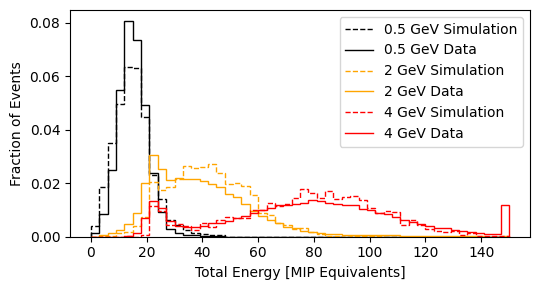

In [6]:
fig, ax = plt.subplots(1,1,figsize=(5.5,3))

#Low energy electrons
#bins = np.linspace(0,50,51)

bins = np.linspace(0,150,51)

sum_pion_0p5GeV_mc = [0.004079782411604714, 0.018736778482925355, 0.03505590812934421, 0.0495618011483832, 0.06361438501057722, 0.06316107585373225, 0.04487760652765186, 0.023269870051375038, 0.014203686914475672, 0.0061952251435479, 0.004381988516168027, 0.0025687518887881535, 0.0012088244182532487, 0.0010577213659715926, 0.0006044122091266244, 0.0007555152614082804, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sum_pion_0p5GeV_data = [0.0013743150543532757, 0.008529011024012174, 0.02507977515497909, 0.054795651737948196, 0.08078377246533246, 0.07372345006163773, 0.04945764691309964, 0.023687765057007534, 0.009242711116616236, 0.0030730392417083973, 0.0015335704469178185, 0.0007431918319678658, 0.0004954612213119105, 0.00025362895852871613, 0.0002241372191649119, 0.00013566200107349932, 7.66785223458909e-05, 2.359339149104336e-05, 5.308513085484756e-05, 1.7695043618282518e-05, 1.179669574552168e-05, 5.89834787276084e-06, 0.0, 5.89834787276084e-06, 0.0, 0.0, 5.89834787276084e-06, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

ax.stairs(sum_pion_0p5GeV_mc, bins, color="black", linestyle="--", label="0.5 GeV Simulation")
ax.stairs(sum_pion_0p5GeV_data, bins, color="black", label="0.5 GeV Data")

sum_pion_1GeV_mc = [0.0005931198102016607, 0.0034104389086595495, 0.00741399762752076, 0.01230723606168446, 0.02090747330960854, 0.030397390272835112, 0.0400355871886121, 0.05708778173190985, 0.044632265717674965, 0.03692170818505338, 0.028766310794780547, 0.02031435349940688, 0.011417556346381969, 0.007265717674970343, 0.004744958481613285, 0.0029655990510083037, 0.0011862396204033213, 0.0005931198102016607, 0.00029655990510083033, 0.0010379596678529064, 0.00014827995255041517, 0.00014827995255041517, 0.00029655990510083033, 0.0, 0.00014827995255041517, 0.0, 0.00014827995255041517, 0.0, 0.0, 0.00014827995255041517, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sum_pion_1GeV_data = [0.001908923246634607, 0.008540600168916007, 0.014478514918041264, 0.02212713515004223, 0.028969957081545063, 0.03716583070479342, 0.05471241187927676, 0.05917231156385197, 0.034670872330523815, 0.02158419084061568, 0.015223986073047556, 0.01048399607011738, 0.007049657858903425, 0.004580553975558887, 0.003305065756588586, 0.0023829222469276246, 0.0018270506920385406, 0.0013573607735663685, 0.000939379836944344, 0.0007885619732147474, 0.0005213989003223194, 0.00037489011841356846, 0.00034472654566764915, 0.00018098143647551579, 0.00012927245462536843, 0.00014650878190875088, 0.00010341796370029474, 6.894530913352982e-05, 5.170898185014737e-05, 3.447265456676491e-05, 8.618163641691228e-06, 2.5854490925073685e-05, 8.618163641691228e-06, 1.2927245462536842e-05, 1.2927245462536842e-05, 4.309081820845614e-06, 4.309081820845614e-06, 8.618163641691228e-06, 4.309081820845614e-06, 1.2927245462536842e-05, 0.0, 0.0, 4.309081820845614e-06, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

#ax.stairs(sum_pion_1GeV_mc, bins, color="green", linestyle="--", label="1 GeV Simulation")
#ax.stairs(sum_pion_1GeV_data, bins, color="green", label="1 GeV Data")

sum_pion_2GeV_mc = [0.0, 0.0002942041776993233, 0.00014710208884966165, 0.001323918799646955, 0.0016181229773462782, 0.003971756398940865, 0.007502206531332745, 0.02030008826125331, 0.0176522506619594, 0.01868196528390703, 0.021624007060900265, 0.026331273904089438, 0.02559576345984113, 0.026184171815239778, 0.027066784348337748, 0.023683436304795528, 0.019858781994704325, 0.020005884083553988, 0.01912327155045602, 0.0157399235069138, 0.0088261253309797, 0.00794351279788173, 0.00529567519858782, 0.00441306266548985, 0.0029420417769932335, 0.003089143865842895, 0.0016181229773462782, 0.0010297146219476318, 0.000441306266548985, 0.0002942041776993233, 0.0, 0.00014710208884966165, 0.00014710208884966165, 0.0002942041776993233, 0.00014710208884966165, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sum_pion_2GeV_data = [7.464949728229173e-05, 0.0004805561387547531, 0.0013903468868826836, 0.0026873819021625027, 0.004768236638906385, 0.00877131593066928, 0.02012737070473791, 0.030545641169197755, 0.02524552686215504, 0.021340425035575154, 0.021839643548650475, 0.021573704714582313, 0.02162502624396389, 0.020897193645461543, 0.019884759838570465, 0.01850840973242821, 0.01590034292112814, 0.014715282151771758, 0.012083887372570976, 0.009723097021018498, 0.007889518744022208, 0.00640585998553666, 0.004954860382112114, 0.003783796393496162, 0.003191266008817972, 0.0021974945762474633, 0.0018289126834161475, 0.0015256491007068374, 0.001157067207875522, 0.0010544241491123707, 0.000797816502204493, 0.000699839037021485, 0.0006345207268994798, 0.0006438519140597662, 0.000499218513075326, 0.000536543261716472, 0.00048522173233489627, 0.0003499195185107425, 0.0003872442671518884, 0.00032659155061002637, 0.0002706044276483075, 0.00020528611752630227, 0.0001959549303660158, 0.0001819581496255861, 0.00015396458814472672, 0.00014463340098444025, 8.864627802272144e-05, 7.931509086243498e-05, 6.065271654186203e-05, 0.000419903422212891]

ax.stairs(sum_pion_2GeV_mc, bins, color="orange", linestyle="--", label="2 GeV Simulation")
ax.stairs(sum_pion_2GeV_data, bins, color="orange", label="2 GeV Data")

sum_pion_3GeV_mc = [0.0, 0.0, 0.0, 0.00014801657785671994, 0.00014801657785671994, 0.0002960331557134399, 0.0014801657785671995, 0.013765541740674956, 0.009473060982830076, 0.007400828892835998, 0.006956779159265837, 0.0063647128478389586, 0.010065127294256957, 0.010065127294256957, 0.010065127294256957, 0.012877442273534635, 0.016281823564239194, 0.017465956187092957, 0.020130254588513915, 0.020574304322084073, 0.018354055654233276, 0.018502072232089994, 0.01983422143280047, 0.018058022498519833, 0.015393724097098873, 0.018058022498519833, 0.012433392539964476, 0.011249259917110717, 0.009029011249259917, 0.008436944937833037, 0.006512729425695678, 0.004440497335701598, 0.002812314979277679, 0.0017761989342806395, 0.0020722320899940793, 0.0010361160449970396, 0.00014801657785671994, 0.0002960331557134399, 0.0002960331557134399, 0.0002960331557134399, 0.0002960331557134399, 0.00014801657785671994, 0.00014801657785671994, 0.0, 0.00014801657785671994, 0.0, 0.0, 0.0, 0.0, 0.0]
sum_pion_3GeV_data = [0.0, 4.60116728074553e-05, 0.0001344956589756386, 0.0003079242718652778, 0.0005662975114763731, 0.0024386186587951313, 0.008802386944010874, 0.015905881353592628, 0.012331128312398021, 0.008505080750485778, 0.007436194197574124, 0.00797063747402995, 0.008890870930179057, 0.01023936687938217, 0.011336568307867643, 0.012327588952951295, 0.013665466823814226, 0.014150359068015872, 0.014624633233877332, 0.01477328633063988, 0.01418929202192987, 0.014065414441294416, 0.013569904118752588, 0.012709839773197847, 0.012423151658012933, 0.011863932865430013, 0.011371961902334915, 0.010695944248009995, 0.010264142395509261, 0.008912107086859421, 0.00802372786573086, 0.007117651847368664, 0.0055037039396610005, 0.004218916460498979, 0.003489808414473149, 0.0025483388016436783, 0.0020209742440813064, 0.0015750149537936626, 0.001249393884694748, 0.0010511897556780175, 0.0008034345944071043, 0.0008494462672145595, 0.0007291080460258303, 0.0006689389354314656, 0.0006158485437305556, 0.0005698368709231003, 0.00047073480641473506, 0.0005167464792221904, 0.0006052304653903737, 0.006186800312879374]

#ax.stairs(sum_pion_3GeV_mc, bins, color="purple", linestyle="--", label="3 GeV Simulation")
#ax.stairs(sum_pion_3GeV_data, bins, color="purple", label="3 GeV Data")

sum_pion_4GeV_mc = [0.0, 0.0, 0.0, 0.0, 0.00015130882130428203, 0.0, 0.0007565441065214102, 0.011348161597821153, 0.009532455742169769, 0.004539264639128461, 0.004690573460432743, 0.0040853381752156154, 0.002572249962172795, 0.004993191103041307, 0.003480102889998487, 0.006354970494779845, 0.007565441065214102, 0.006960205779996974, 0.0071115146013012555, 0.009835073384778334, 0.010137691027386896, 0.01270994098955969, 0.011499470419125435, 0.012407323346951127, 0.014525646845211076, 0.01785444091390528, 0.016341352700862462, 0.014525646845211076, 0.01709789680738387, 0.01407172038129823, 0.014676955666515359, 0.015130882130428205, 0.013769102738689665, 0.010591617491299742, 0.008775911635648358, 0.009532455742169769, 0.009381146920865486, 0.004387955817824179, 0.006203661673475564, 0.004236646996519897, 0.0027235587834770767, 0.0019670146769556664, 0.0016643970343471024, 0.0019670146769556664, 0.0006052352852171281, 0.0015130882130428205, 0.00015130882130428203, 0.00030261764260856405, 0.00030261764260856405, 0.00030261764260856405]
sum_pion_4GeV_data = [5.101598330757026e-06, 3.5711188315299184e-05, 4.0812786646056205e-05, 7.65239749613554e-05, 0.00023467352321482321, 0.0013213139676660696, 0.00718815204803665, 0.013391695618237194, 0.0106011213313131, 0.0060300892269548045, 0.003948637108005938, 0.0035966268231837034, 0.0037445731747756572, 0.004045567476290321, 0.004968956774157344, 0.00524954468234898, 0.005979073243647235, 0.007009596106460154, 0.00789217261768112, 0.008825765112209654, 0.010167485473198753, 0.010897014034497008, 0.011713269767418133, 0.012029568863925068, 0.012269343985470648, 0.012657065458608181, 0.013580454756475204, 0.013182530086676155, 0.012784605416877108, 0.012427493533724117, 0.011799996939041001, 0.01174898095573343, 0.010356244611436763, 0.00993281194998393, 0.008815561915548142, 0.008453348434064393, 0.007504451144543585, 0.006223949963523572, 0.005453608615579261, 0.004826112020896146, 0.004132294647913191, 0.003433375676599479, 0.003096670186769515, 0.0025354943703862418, 0.0019947249473259974, 0.0016580194574960334, 0.001392736344296668, 0.0011376564277588168, 0.0010050148711591342, 0.01193774009397144]

ax.stairs(sum_pion_4GeV_mc, bins, color="red", linestyle="--", label="4 GeV Simulation")
ax.stairs(sum_pion_4GeV_data, bins, color="red", label="4 GeV Data")

ax.set_xlabel("Total Energy [MIP Equivalents]")
ax.set_ylabel("Fraction of Events")
ax.legend()
plt.tight_layout()
plt.savefig("plots/datamccomparisons/energysum_pion_combined.pdf")

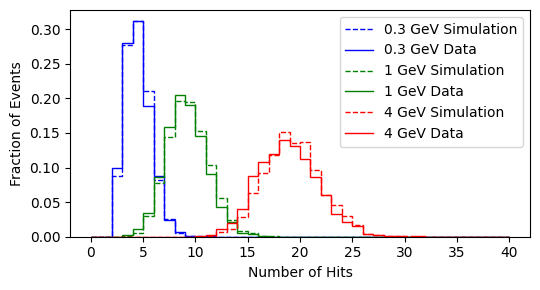

In [494]:
fig, ax = plt.subplots(1,1,figsize=(5.5,3))

nHitsBins = np.linspace(0,40,41)

nhits_electron_0p3GeV_mc = [0.0, 0.0, 0.08795493934142114, 0.27642980935875217, 0.3119584055459272, 0.21013864818024264, 0.0818890814558059, 0.02512998266897747, 0.005632582322357019, 0.0004332755632582322, 0.0004332755632582322, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
nhits_electron_0p3GeV_data = [0.0, 0.0, 0.09865858935525747, 0.2799653829511034, 0.3115534400692341, 0.1890956295975768, 0.08740804846386846, 0.023799221116399826, 0.0073561228905235825, 0.0017308524448290783, 0.0, 0.00043271311120726956, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

ax.stairs(nhits_electron_0p3GeV_mc, nHitsBins, color="blue", linestyle="--", label="0.3 GeV Simulation")
ax.stairs(nhits_electron_0p3GeV_data, nHitsBins, color="blue", label="0.3 GeV Data")

nhits_electron_1GeV_mc = [0.0, 0.0, 0.0, 0.0008087343307723412, 0.005256773150020219, 0.029518803073190457, 0.07763849575414476, 0.1447634452082491, 0.19652244237767894, 0.1940962393853619, 0.1528507885159725, 0.10311362717347351, 0.055802668823291546, 0.02466639708855641, 0.008896077638495753, 0.004852405984634048, 0.0008087343307723412, 0.0004043671653861706, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
nhits_electron_1GeV_data = [0.0, 0.0, 0.00027464982147761604, 0.0021971985718209283, 0.01043669321614941, 0.033781928041746775, 0.08678934358692666, 0.15874759681406206, 0.20488876682230156, 0.19088162592694316, 0.14583905520461413, 0.09090909090909091, 0.04257072232903049, 0.02087338643229882, 0.006042296072507553, 0.004394397143641857, 0.0010985992859104642, 0.00027464982147761604, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

ax.stairs(nhits_electron_1GeV_mc, nHitsBins, color="green", linestyle="--", label="1 GeV Simulation")
ax.stairs(nhits_electron_1GeV_data, nHitsBins, color="green", label="1 GeV Data")

nhits_electron_4GeV_mc = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0004462293618920125, 0.006693440428380187, 0.011601963409192326, 0.028112449799196786, 0.06336456938866578, 0.09236947791164658, 0.11735832217759928, 0.15171798304328424, 0.13476126729138777, 0.13743864346273985, 0.09593931280678268, 0.05979473449352968, 0.04551539491298527, 0.02989736724676484, 0.01651048639000446, 0.004016064257028112, 0.0022311468094600626, 0.000892458723784025, 0.000892458723784025, 0.0004462293618920125, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
nhits_electron_4GeV_data = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0009279307145066501, 0.0024744819053510673, 0.010516548097742036, 0.020414475719146303, 0.03990102072378596, 0.087534797401794, 0.10856789359727807, 0.11970306217135787, 0.14042684812867307, 0.13176616145994433, 0.11197030621713579, 0.08598824621094958, 0.060315496442932263, 0.03278688524590164, 0.02103309619548407, 0.015774822146613052, 0.004330343334364367, 0.003093102381688834, 0.0006186204763377668, 0.0009279307145066501, 0.0003093102381688834, 0.0006186204763377668, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

ax.stairs(nhits_electron_4GeV_mc, nHitsBins, color="red", linestyle="--", label="4 GeV Simulation")
ax.stairs(nhits_electron_4GeV_data, nHitsBins, color="red", label="4 GeV Data")

ax.set_xlabel("Number of Hits")
ax.set_ylabel("Fraction of Events")
ax.legend()
plt.tight_layout()
plt.savefig("plots/datamccomparisons/nhits_combined.pdf")

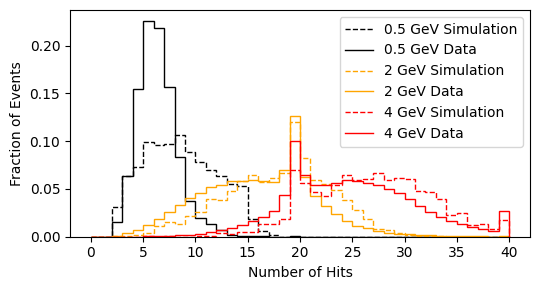

In [4]:
fig, ax = plt.subplots(1,1,figsize=(5.5,3))

nHitsBins = np.linspace(0,40,41)

nhits_pion_0p5GeV_mc = [0.0, 0.0, 0.030825022665457842, 0.06391659111514053, 0.07252946509519492, 0.09927470534904805, 0.0956482320942883, 0.09655485040797825, 0.10652765185856754, 0.0883952855847688, 0.07842248413417952, 0.06980961015412511, 0.06391659111514053, 0.05485040797824116, 0.053037171350861285, 0.0185856754306437, 0.0058930190389845875, 0.001813236627379873, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
nhits_pion_0p5GeV_data = [0.0, 0.0, 0.015164652380868119, 0.06402066781094616, 0.15461929113655265, 0.22601879213632262, 0.2180383274644772, 0.15621184506219807, 0.08383911666342257, 0.03703572629306531, 0.01939376780563764, 0.013536708367986127, 0.007538088581388353, 0.0019641498416293596, 0.000884752180914126, 0.000477766177693628, 0.00038929095960221543, 0.00023003556703767275, 0.00010617026170969512, 0.0003362058287473679, 8.84752180914126e-05, 5.308513085484756e-05, 0.0, 3.5390087236565036e-05, 1.7695043618282518e-05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

ax.stairs(nhits_pion_0p5GeV_mc, nHitsBins, color="black", linestyle="--", label="0.5 GeV Simulation")
ax.stairs(nhits_pion_0p5GeV_data, nHitsBins, color="black", label="0.5 GeV Data")

nhits_pion_1GeV_mc = [0.0, 0.0, 0.004893238434163701, 0.013790035587188613, 0.023576512455516015, 0.037366548042704624, 0.04848754448398576, 0.06717081850533808, 0.074288256227758, 0.06983985765124555, 0.09119217081850534, 0.06672597864768683, 0.07873665480427046, 0.05827402135231317, 0.0653914590747331, 0.04759786476868327, 0.04048042704626335, 0.037366548042704624, 0.03692170818505338, 0.08807829181494661, 0.03291814946619217, 0.008896797153024912, 0.005338078291814947, 0.0017793594306049821, 0.0008896797153024911, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
nhits_pion_1GeV_data = [0.0, 0.0, 0.013896788872227107, 0.0304565903097368, 0.04318992709033559, 0.054682248306530845, 0.06532137132219866, 0.07271575572676973, 0.07488753296447594, 0.07006567040694969, 0.06320130306634263, 0.05547081027974559, 0.051605563886447076, 0.046615647137907855, 0.04289260044469725, 0.03772170225968251, 0.03410207353017219, 0.03620921454056569, 0.05686695278969957, 0.11675888101763277, 0.01874450592067842, 0.005235534412327421, 0.0024561766378820003, 0.0020295775376182844, 0.0015383422100418843, 0.001150524846165779, 0.0009824706551528001, 0.0005170898185014737, 0.00018098143647551579, 0.00018098143647551579, 0.00016805419101297895, 7.756347277522106e-05, 2.5854490925073685e-05, 1.2927245462536842e-05, 1.2927245462536842e-05, 0.0, 0.0, 2.5854490925073685e-05, 0.0, 0.0]

#ax.stairs(nhits_pion_1GeV_mc, nHitsBins, color="green", linestyle="--", label="1 GeV Simulation")
#ax.stairs(nhits_pion_1GeV_data, nHitsBins, color="green", label="1 GeV Data")

nhits_pion_2GeV_mc = [0.0, 0.0, 0.00088261253309797, 0.000441306266548985, 0.00176522506619594, 0.00441306266548985, 0.011032656663724626, 0.015445719329214475, 0.012797881729920565, 0.02118270079435128, 0.02559576345984113, 0.03971756398940865, 0.03795233892321271, 0.04766107678729038, 0.05825242718446602, 0.06443071491615181, 0.05692850838481906, 0.061341571050308914, 0.06663724624889673, 0.12003530450132392, 0.0825242718446602, 0.05913503971756399, 0.05472197705207414, 0.04854368932038835, 0.03795233892321271, 0.027802294792586054, 0.018534863195057368, 0.00794351279788173, 0.007502206531332745, 0.00441306266548985, 0.002206531332744925, 0.00088261253309797, 0.00088261253309797, 0.000441306266548985, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
nhits_pion_2GeV_data = [0.0, 0.0, 0.0008960322571612578, 0.004102147677316383, 0.007168258057290063, 0.01246044857614874, 0.018256657239660627, 0.02599893596169462, 0.033055189986839525, 0.040153445524038864, 0.045333632010752384, 0.051731862347044494, 0.05416795004620166, 0.05841010276369949, 0.05815809369137289, 0.05925013300478817, 0.058690112844062385, 0.05713605689804833, 0.07001652059474141, 0.12638254977179178, 0.06262425447316103, 0.042799540783468204, 0.03201915268949682, 0.023730854310755188, 0.015974575084703048, 0.011480413294878616, 0.008610309971158962, 0.005586201103239717, 0.003948142133116792, 0.002982107355864811, 0.002422087195139025, 0.001540055441995912, 0.0014840534259233332, 0.0009100327611794025, 0.0007420267129616666, 0.0004900176406350628, 0.00043401562456248425, 0.0003500126004536163, 0.00022400806429031446, 0.00028001008036289307]

ax.stairs(nhits_pion_2GeV_mc, nHitsBins, color="orange", linestyle="--", label="2 GeV Simulation")
ax.stairs(nhits_pion_2GeV_data, nHitsBins, color="orange", label="2 GeV Data")

#nhits_pion_3GeV_mc = [0.0, 0.0, 0.0, 0.0, 0.0004440497335701599, 0.0004440497335701599, 0.002220248667850799, 0.0017761989342806395, 0.0013321492007104796, 0.005772646536412078, 0.0066607460035523975, 0.009325044404973356, 0.015097690941385435, 0.013765541740674956, 0.023978685612788632, 0.02486678507992895, 0.02575488454706927, 0.03463587921847247, 0.041740674955595025, 0.10124333925399645, 0.07149200710479574, 0.07015985790408526, 0.06216696269982238, 0.06261101243339254, 0.0719360568383659, 0.06660746003552398, 0.05772646536412078, 0.0497335701598579, 0.05150976909413854, 0.03907637655417407, 0.024422735346358793, 0.022202486678507993, 0.013765541740674956, 0.009325044404973356, 0.006216696269982238, 0.003552397868561279, 0.004440497335701598, 0.0017761989342806395, 0.0008880994671403197, 0.0013321492007104796]
#nhits_pion_3GeV_data = [0.0, 0.0, 8.494462672145595e-05, 0.00038225082024655177, 0.0006689389354314656, 0.001794455239490757, 0.003111096953673324, 0.005022351054906083, 0.007209675192983574, 0.010034084031471983, 0.013198271376846218, 0.017859607768186115, 0.025334734919674237, 0.03303284171630618, 0.039987683029125386, 0.046422238503275676, 0.05262319625394196, 0.05661559370985039, 0.0692829611696875, 0.12044086261268436, 0.07847821701228512, 0.06277407914715595, 0.05645632253474766, 0.05238959853045796, 0.04807865872434407, 0.04141050552670977, 0.03458308115397275, 0.029051062338737936, 0.0209919408785398, 0.017434884634578835, 0.013134562906805126, 0.009343908939360155, 0.007177820957963028, 0.005266566856730269, 0.004406502511175528, 0.003217277737075144, 0.0026226653500249523, 0.002208560294757855, 0.001805073317830939, 0.006062922732243918]

#ax.stairs(nhits_pion_3GeV_mc, nHitsBins, color="purple", linestyle="--", label="3 GeV Simulation")
#ax.stairs(nhits_pion_3GeV_data, nHitsBins, color="purple", label="3 GeV Data")

nhits_pion_4GeV_mc = [0.0, 0.0, 0.0, 0.0, 0.0, 0.00045392646391284613, 0.0, 0.00045392646391284613, 0.0, 0.0, 0.0009078529278256923, 0.0009078529278256923, 0.003631411711302769, 0.0027235587834770767, 0.005447117566954153, 0.004539264639128461, 0.013617793917385384, 0.013163867453472538, 0.018157058556513846, 0.07035860190649115, 0.055832955061280075, 0.04675442578302315, 0.04312301407172038, 0.05401724920562869, 0.064911484339537, 0.05901044030867, 0.05991829323649569, 0.06672719019518839, 0.05901044030867, 0.06173399909214707, 0.06082614616432138, 0.048116205174761686, 0.0463004993191103, 0.03949160236041761, 0.02315024965955515, 0.024965955515206535, 0.01270994098955969, 0.013617793917385384, 0.007716749886518384, 0.017703132092601]
nhits_pion_4GeV_data = [0.0, 0.0, 7.65239749613554e-05, 6.121917996908431e-05, 0.00012243835993816862, 0.00024487671987633724, 0.000581582209706301, 0.0009642020845130779, 0.0014080411392889392, 0.0022038904788870355, 0.003275226128346011, 0.0046067432926735945, 0.00667289061663019, 0.008983914660463123, 0.012718284638577266, 0.016192473101822803, 0.020477815699658702, 0.026416076156659883, 0.04366458011294939, 0.09978726334960743, 0.06435666294249988, 0.05422488865761643, 0.054286107837585515, 0.056398169546518925, 0.05916833744011999, 0.05809700179066101, 0.056168597621634855, 0.054316717427570056, 0.04997015564976507, 0.04533280276710693, 0.03904253202528352, 0.03206354550880791, 0.026370161771683068, 0.020309462954743722, 0.016544483386645038, 0.013269257258299026, 0.010269517439813894, 0.007881969421019605, 0.006121917996908432, 0.027349668651188416]

ax.stairs(nhits_pion_4GeV_mc, nHitsBins, color="red", linestyle="--", label="4 GeV Simulation")
ax.stairs(nhits_pion_4GeV_data, nHitsBins, color="red", label="4 GeV Data")

ax.set_xlabel("Number of Hits")
ax.set_ylabel("Fraction of Events")
ax.legend()
plt.tight_layout()
plt.savefig("plots/datamccomparisons/nhits_pion_combined.pdf")

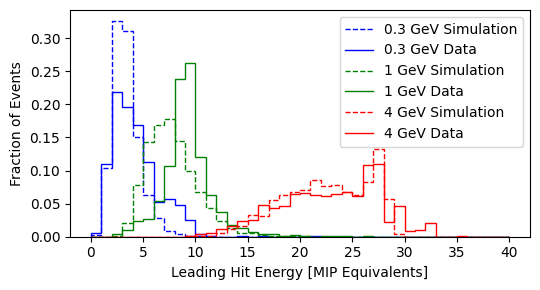

In [496]:
fig, ax = plt.subplots(1,1,figsize=(5.5,3))
bins = np.linspace(0,40,41)

leadinghit_electron_0p3GeV_mc = [0.0030329289428076256, 0.10441941074523396, 0.3262564991334489, 0.31109185441941073, 0.15077989601386482, 0.06282495667244367, 0.02772963604852686, 0.008665511265164644, 0.00389948006932409, 0.0004332755632582322, 0.0008665511265164644, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
leadinghit_electron_0p3GeV_data = [0.005192557334487235, 0.11034184335785374, 0.21938554738208568, 0.1964517524881004, 0.16832540025962786, 0.11337083513630462, 0.05192557334487235, 0.05668541756815231, 0.04846386845521419, 0.024664647338814367, 0.0034617048896581565, 0.00043271311120726956, 0.0, 0.0, 0.00043271311120726956, 0.0, 0.00043271311120726956, 0.0, 0.0, 0.0, 0.0, 0.00043271311120726956, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

ax.stairs(leadinghit_electron_0p3GeV_mc, bins, color="blue", linestyle="--", label="0.3 GeV Simulation")
ax.stairs(leadinghit_electron_0p3GeV_data, bins, color="blue", label="0.3 GeV Data")

leadinghit_electron_1GeV_mc = [0.0, 0.0, 0.0016174686615446825, 0.021431459765467044, 0.07844723008491711, 0.1431459765467044, 0.16902547513141933, 0.1779215527699151, 0.14516781237363527, 0.09906995551961181, 0.06752931661949049, 0.04326728669632026, 0.023453295592397897, 0.01293974929235746, 0.00606550748079256, 0.00606550748079256, 0.003234937323089365, 0.0004043671653861706, 0.0004043671653861706, 0.0004043671653861706, 0.0004043671653861706, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
leadinghit_electron_1GeV_data = [0.0, 0.0, 0.004119747322164241, 0.010711343037627026, 0.023894534468552595, 0.027464982147761604, 0.05328206536665751, 0.10711343037627026, 0.23894534468552595, 0.2617412798681681, 0.12057127162867344, 0.0631694589398517, 0.03680307607800055, 0.017852238396045043, 0.012908541609447955, 0.006866245536940401, 0.0035704476792090085, 0.0035704476792090085, 0.0010985992859104642, 0.0019225487503433123, 0.0005492996429552321, 0.00027464982147761604, 0.0008239494644328481, 0.0005492996429552321, 0.0008239494644328481, 0.00027464982147761604, 0.0005492996429552321, 0.00027464982147761604, 0.0, 0.0, 0.0, 0.0, 0.00027464982147761604, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

ax.stairs(leadinghit_electron_1GeV_mc, bins, color="green", linestyle="--", label="1 GeV Simulation")
ax.stairs(leadinghit_electron_1GeV_data, bins, color="green", label="1 GeV Data")

leadinghit_electron_4GeV_mc = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0004462293618920125, 0.000892458723784025, 0.0013386880856760374, 0.00535475234270415, 0.011155734047300312, 0.01606425702811245, 0.03257474341811691, 0.031236055332440876, 0.05488621151271754, 0.06247211066488175, 0.06738063364569388, 0.07005800981704596, 0.08522980812137439, 0.07630522088353414, 0.0785363676929942, 0.06693440428380187, 0.06247211066488175, 0.08299866131191433, 0.13297634984381973, 0.05667112896028559, 0.004016064257028112, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
leadinghit_electron_4GeV_data = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0003093102381688834, 0.0, 0.0003093102381688834, 0.0009279307145066501, 0.0046396535725332505, 0.005258274048871018, 0.011135168574079802, 0.015774822146613052, 0.023507578100835137, 0.025982060006186206, 0.04825239715434581, 0.04330343334364367, 0.04701515620167027, 0.06433652953912775, 0.06619239096814104, 0.06278997834828333, 0.06124342715743891, 0.06402721930095887, 0.06742963192081658, 0.060934116919270025, 0.10856789359727807, 0.10949582431178471, 0.022270337148159604, 0.045777915248994744, 0.008660686668728735, 0.010825858335910918, 0.020414475719146303, 0.0, 0.0, 0.0006186204763377668, 0.0, 0.0, 0.0, 0.0]

ax.stairs(leadinghit_electron_4GeV_mc, bins, color="red", linestyle="--", label="4 GeV Simulation")
ax.stairs(leadinghit_electron_4GeV_data, bins, color="red", label="4 GeV Data")

ax.set_xlabel("Leading Hit Energy [MIP Equivalents]")
ax.set_ylabel("Fraction of Events")
ax.legend()
plt.tight_layout()
plt.savefig("plots/datamccomparisons/leadinghit_combined.pdf")
plt.show()

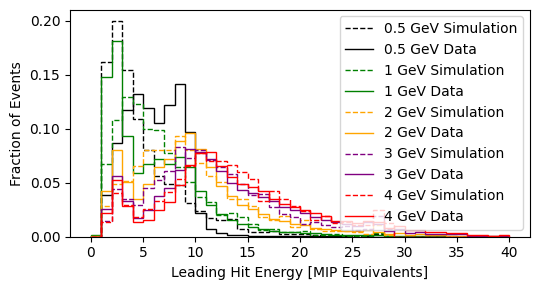

In [818]:
fig, ax = plt.subplots(1,1,figsize=(5.5,3))
bins = np.linspace(0,40,41)

leadinghit_pion_0p5GeV_mc = [0.00045330915684496827, 0.16183136899365366, 0.19990933816863102, 0.1541251133272892, 0.10924750679963735, 0.08023572076155938, 0.05666364460562103, 0.04895738893925657, 0.047597461468721666, 0.03127833182230281, 0.02402538531278332, 0.017679057116953764, 0.01586582048957389, 0.016772438803263828, 0.006799637352674524, 0.004079782411604714, 0.004533091568449683, 0.005439709882139619, 0.0027198549410698096, 0.0022665457842248413, 0.0022665457842248413, 0.0013599274705349048, 0.0, 0.0, 0.00045330915684496827, 0.0009066183136899365, 0.0013599274705349048, 0.0022665457842248413, 0.0009066183136899365, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
leadinghit_pion_0p5GeV_data = [0.0009024472245324085, 0.039070656309167805, 0.08640489798807353, 0.11689345814237433, 0.132093500610479, 0.11963618990320811, 0.10487852352556049, 0.12193654557358484, 0.14145417868455046, 0.09693344894095164, 0.021587953214304675, 0.007201882752640985, 0.003167412807672571, 0.0016456390565002743, 0.0011855679224249288, 0.0007431918319678658, 0.0006016314830216056, 0.0004954612213119105, 0.0004600711340753455, 0.00042468104683878046, 0.0003362058287473679, 0.0003008157415108028, 0.00042468104683878046, 0.00023003556703767275, 0.0003185107851290853, 0.0001769504361828252, 0.0003008157415108028, 3.5390087236565036e-05, 5.308513085484756e-05, 3.5390087236565036e-05, 1.7695043618282518e-05, 3.5390087236565036e-05, 1.7695043618282518e-05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

ax.stairs(leadinghit_pion_0p5GeV_mc, bins, color="black", linestyle="--", label="0.5 GeV Simulation")
ax.stairs(leadinghit_pion_0p5GeV_data, bins, color="black", label="0.5 GeV Data")

leadinghit_pion_1GeV_mc = [0.0008896797153024911, 0.06761565836298933, 0.10809608540925267, 0.1290035587188612, 0.12322064056939502, 0.10008896797153025, 0.09919928825622776, 0.07740213523131673, 0.0645017793594306, 0.050266903914590745, 0.036476868327402136, 0.03202846975088968, 0.020462633451957295, 0.02179715302491103, 0.018238434163701068, 0.01201067615658363, 0.0066725978647686835, 0.0071174377224199285, 0.00400355871886121, 0.004448398576512456, 0.004893238434163701, 0.0017793594306049821, 0.0017793594306049821, 0.002224199288256228, 0.0008896797153024911, 0.0008896797153024911, 0.00044483985765124553, 0.003113879003558719, 0.00044483985765124553, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
leadinghit_pion_1GeV_data = [0.0018228123020438767, 0.14758315773143899, 0.180846250307034, 0.09366152573268005, 0.058743681563740255, 0.06759918813749952, 0.07183948909544556, 0.06762504363114553, 0.07353302392925937, 0.06439310692539398, 0.04257107028815948, 0.029746745439737307, 0.02116272154926118, 0.015034969555156232, 0.012048660039041795, 0.008739156852352204, 0.00738174343593655, 0.005623569868007705, 0.004602277868990214, 0.004201517717477021, 0.003736118831848797, 0.0029992372629374427, 0.002443344149548175, 0.0019262342766279265, 0.0018098845552208705, 0.0016030406060527711, 0.001706462580636821, 0.0013832689100616653, 0.0006851705816193295, 0.000711026075265342, 0.0004524711388052176, 0.00046539888562822387, 0.00032319367057515546, 0.0002844104301061368, 0.00023269944281411193, 0.00016806070869908083, 7.756648093803732e-05, 0.0001292774682300622, 7.756648093803732e-05, 2.5855493646012436e-05]

ax.stairs(leadinghit_pion_1GeV_mc, bins, color="green", linestyle="--", label="1 GeV Simulation")
ax.stairs(leadinghit_pion_1GeV_data, bins, color="green", label="1 GeV Data")

leadinghit_pion_2GeV_mc = [0.0, 0.02824360105913504, 0.04854368932038835, 0.05163283318623124, 0.06531332744924978, 0.08031774051191527, 0.08031774051191527, 0.07987643424536628, 0.09355692850838482, 0.08031774051191527, 0.06796116504854369, 0.05648720211827008, 0.05030891438658429, 0.03486319505736982, 0.03486319505736982, 0.028684907325684024, 0.018534863195057368, 0.015445719329214475, 0.018976169461606355, 0.009267431597528684, 0.015445719329214475, 0.00706090026478376, 0.0048543689320388345, 0.0048543689320388345, 0.0048543689320388345, 0.00441306266548985, 0.00264783759929391, 0.01059135039717564, 0.00176522506619594, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
leadinghit_pion_2GeV_data = [0.0002520020160161281, 0.04261634093072745, 0.08048664389315115, 0.05096040768326147, 0.035336282690261525, 0.04919639357114857, 0.06483451867614941, 0.07200257602060817, 0.08824270594164753, 0.09625077000616004, 0.08128465027720222, 0.06426051408411267, 0.04719437755502044, 0.0378563028504228, 0.02952623620988968, 0.026110208881671055, 0.021182169457355658, 0.016072128577028617, 0.014602116816934536, 0.012040096320770566, 0.010794086352690822, 0.008400067200537605, 0.0074760598084784675, 0.005964047712381699, 0.004998039984319875, 0.0050120400963207705, 0.006132049056392451, 0.004816038528308226, 0.0028980231841854733, 0.0033180265442123535, 0.0018340146721173769, 0.002338018704149633, 0.0011620092960743687, 0.0012880103040824327, 0.0010780086240689925, 0.0007980063840510724, 0.00044800358402867225, 0.0005460043680349443, 0.00022400179201433613, 0.00016800134401075207]

ax.stairs(leadinghit_pion_2GeV_mc, bins, color="orange", linestyle="--", label="2 GeV Simulation")
ax.stairs(leadinghit_pion_2GeV_data, bins, color="orange", label="2 GeV Data")

leadinghit_pion_3GeV_mc = [0.0, 0.014209591474245116, 0.04440497335701599, 0.03507992895204263, 0.02975133214920071, 0.0452930728241563, 0.052397868561278864, 0.0608348134991119, 0.0830373001776199, 0.07326820603907638, 0.08037300177619894, 0.07060390763765542, 0.06438721136767318, 0.05772646536412078, 0.04840142095914742, 0.038632326820603906, 0.03952042628774423, 0.027531083481349913, 0.020870337477797513, 0.018206039076376555, 0.011989342806394316, 0.013321492007104795, 0.011101243339253997, 0.009325044404973356, 0.010213143872113677, 0.005772646536412078, 0.007104795737122558, 0.019094138543516874, 0.007548845470692718, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
leadinghit_pion_3GeV_data = [1.0623492791960141e-05, 0.025528253179080217, 0.05627264131901286, 0.032975321626244274, 0.017231305308559347, 0.024455280407092245, 0.03728845969978009, 0.04518171484420648, 0.061403788337529616, 0.08124847287291116, 0.0788369400091362, 0.07197416366552996, 0.06049016795742104, 0.04937799449703073, 0.043311980112821495, 0.04084732978508674, 0.03709723682952481, 0.03279472224878095, 0.027876045086103408, 0.02496520806110633, 0.02189501864422985, 0.018421136501258883, 0.015489052490677885, 0.013534329816957218, 0.01211078178283456, 0.010230423558657616, 0.013757423165588383, 0.011770830013491836, 0.004950547641053425, 0.007266469069700736, 0.003866951376273491, 0.004578725393334821, 0.002953330996164919, 0.002507144298902593, 0.002209686500727709, 0.0022840509502714303, 0.0009348673656924924, 0.0008923733945246518, 0.0005630451179738875, 0.0006161625819336882]

ax.stairs(leadinghit_pion_3GeV_mc, bins, color="purple", linestyle="--", label="3 GeV Simulation")
ax.stairs(leadinghit_pion_3GeV_data, bins, color="purple", label="3 GeV Data")

leadinghit_pion_4GeV_mc = [0.0, 0.013617793917385384, 0.04085338175215615, 0.029051293690422152, 0.018157058556513846, 0.025873808443032227, 0.03313663186563777, 0.04176123467998184, 0.053109396277803, 0.06536541080344985, 0.07762142532909669, 0.0699046754425783, 0.0699046754425783, 0.06627326373127554, 0.05946436677258284, 0.053109396277803, 0.032682705401724924, 0.04221516114389469, 0.03495233772128915, 0.028597367226509306, 0.024058102587380843, 0.015433499773036768, 0.019064911484339538, 0.013163867453472538, 0.013617793917385384, 0.010894235133908307, 0.01044030866999546, 0.024965955515206535, 0.01270994098955969, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
leadinghit_pion_4GeV_data = [0.0, 0.02182870973177494, 0.052817818354498246, 0.028630076132412186, 0.013388275302155297, 0.015211164044668433, 0.024540065256353303, 0.03203075933273081, 0.04793125105313951, 0.06678819258283421, 0.07761829628835343, 0.07823103200012255, 0.0655780395520902, 0.05557512905745929, 0.04865121551446822, 0.04643004855930516, 0.04200303304177326, 0.035017845927605276, 0.030667422374044514, 0.02735864953049126, 0.02441751811399948, 0.022226987944424872, 0.018749712780135108, 0.014797567439224276, 0.01461374672569354, 0.013127862624653422, 0.014659701904076224, 0.01407760297789556, 0.008195340144911996, 0.010309278350515464, 0.006586908901518053, 0.006602227294312281, 0.00419723962561848, 0.004166602840030024, 0.0038755533769396916, 0.0033394096291417103, 0.0019760726704554157, 0.001577794457805487, 0.001041650710007506, 0.0011641978523613302]

ax.stairs(leadinghit_pion_4GeV_mc, bins, color="red", linestyle="--", label="4 GeV Simulation")
ax.stairs(leadinghit_pion_4GeV_data, bins, color="red", label="4 GeV Data")

ax.set_xlabel("Leading Hit Energy [MIP Equivalents]")
ax.set_ylabel("Fraction of Events")
ax.legend()
plt.tight_layout()
plt.savefig("plots/datamccomparisons/leadinghit_pion_combined.pdf")
plt.show()

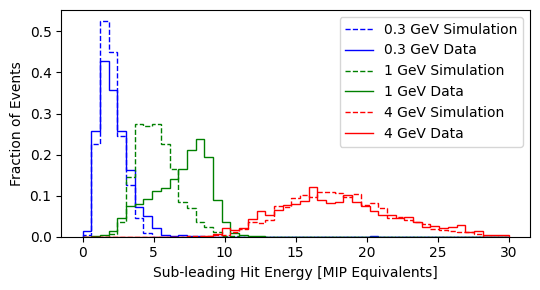

In [498]:
fig, ax = plt.subplots(1,1,figsize=(5.5,3))
bins = np.linspace(0,30,50)

subleadinghit_electron_0p3GeV_mc = [0.004953783939919122, 0.22575101097631425, 0.5258087810514154, 0.4507943385326401, 0.24485846331600222, 0.12596764875794342, 0.04529173887926056, 0.00990756787983824, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
subleadinghit_electron_0p3GeV_data = [0.013428530217798931, 0.25726236838309535, 0.4275926727246502, 0.35620943314582426, 0.25655560363479, 0.16255589211019766, 0.07209000432713114, 0.050887061877974885, 0.0212029424491562, 0.004947353238136447, 0.0014135294966104155, 0.00424058848983124, 0.0014135294966104133, 0.002827058993220831, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0007067647483052078, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

ax.stairs(subleadinghit_electron_0p3GeV_mc, bins, color="blue", linestyle="--", label="0.3 GeV Simulation")
ax.stairs(subleadinghit_electron_0p3GeV_data, bins, color="blue", label="0.3 GeV Data")

subleadinghit_electron_1GeV_mc = [0.0, 0.0, 0.0, 0.007265130071438199, 0.036325650357190986, 0.14596306779889479, 0.27541447634452093, 0.269470279013344, 0.2754144763445207, 0.22653996495484557, 0.1651165925326865, 0.08520016174686612, 0.06934896886372824, 0.036325650357191035, 0.024437255694837536, 0.011888394662353429, 0.001981399110392238, 0.0026418654805229766, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
subleadinghit_electron_1GeV_data = [0.0, 0.0013457841252403184, 0.004037352375720955, 0.013906435960816626, 0.04485947084134393, 0.074466721596631, 0.07984985809759225, 0.09196191522475507, 0.11125148768653295, 0.11842900302114799, 0.13996154902499328, 0.16553144740455913, 0.21039091824590306, 0.23910097958436352, 0.19513869815984586, 0.08882175226586111, 0.03499038725624832, 0.008971894168268775, 0.0044859470841344, 0.0008971894168268774, 0.00134578412524032, 0.00044859470841344, 0.0004485947084134387, 0.00044859470841344, 0.00044859470841344, 0.0004485947084134387, 0.0, 0.0, 0.0, 0.0, 0.00044859470841344, 0.0, 0.00044859470841344, 0.00044859470841344, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

ax.stairs(subleadinghit_electron_1GeV_mc, bins, color="green", linestyle="--", label="1 GeV Simulation")
ax.stairs(subleadinghit_electron_1GeV_data, bins, color="green", label="1 GeV Data")

subleadinghit_electron_4GeV_mc = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0007288412910902868, 0.0007288412910902879, 0.0029153651643611432, 0.005101889037632015, 0.004373047746541727, 0.011661460657444573, 0.01967871485943777, 0.034984381972333715, 0.03425554068124353, 0.0415439535921464, 0.07579949427338972, 0.07142644652684821, 0.09474936784173743, 0.10058009817045943, 0.09693589171500828, 0.11005503495463347, 0.11005503495463347, 0.1064108284991814, 0.09620705042391799, 0.10422430462591116, 0.0779860181466608, 0.08090138331102195, 0.06996876394466722, 0.046645842629778424, 0.048832366503049285, 0.04081511230105612, 0.035713223263424104, 0.03206901680797248, 0.018221032277257198, 0.017492190986166906, 0.01311914323962518, 0.010932619366354318, 0.010932619366354318, 0.007288412910902837, 0.0, 0.0, 0.0]
subleadinghit_electron_4GeV_data = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0005053630363036301, 0.0, 0.0005053630363036301, 0.0, 0.0005053630363036301, 0.0, 0.0, 0.0025268151815181473, 0.007075082508250833, 0.020214521452145234, 0.016171617161716143, 0.02223597359735976, 0.043461221122112134, 0.0636757425742575, 0.052557755775577614, 0.0651918316831682, 0.07630981848184827, 0.08085808580858093, 0.08742780528052789, 0.12027640264026415, 0.09045998349834992, 0.08287953795379548, 0.0849009900990095, 0.10107260726072619, 0.08389026402640272, 0.07580445544554464, 0.06266501650165024, 0.05205239273927368, 0.052557755775577614, 0.04497731023102315, 0.04699876237623767, 0.03487004950495053, 0.02425742574257414, 0.026278877887788807, 0.0212252475247525, 0.024257425742574282, 0.02880569306930696, 0.011623349834983511, 0.013139438943894327, 0.0035375412541254164, 0.0035375412541254164, 0.004042904290429047]

ax.stairs(subleadinghit_electron_4GeV_mc, bins, color="red", linestyle="--", label="4 GeV Simulation")
ax.stairs(subleadinghit_electron_4GeV_data, bins, color="red", label="4 GeV Data")


ax.set_xlabel("Sub-leading Hit Energy [MIP Equivalents]")
ax.set_ylabel("Fraction of Events")
ax.legend()
plt.tight_layout()
plt.savefig("plots/datamccomparisons/subleadinghit_combined.pdf")
plt.show()

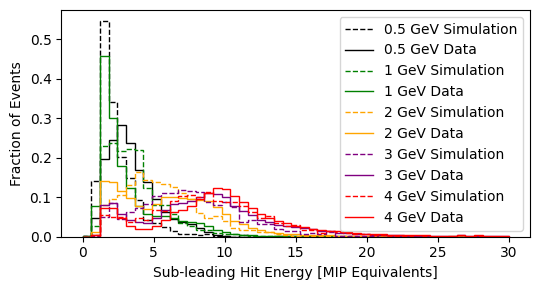

In [820]:
fig, ax = plt.subplots(1,1,figsize=(5.5,3))
bins = np.linspace(0,30,50)

subleadinghit_pion_0p5GeV_mc = [0.0014808099123602297, 0.14215775158658203, 0.5464188576609247, 0.34132668479903294, 0.20064974312481104, 0.14956180114838324, 0.0925506195225144, 0.042943487458446644, 0.03479903294046539, 0.02443336355394378, 0.01554850407978243, 0.006663644605621031, 0.006663644605621031, 0.00518283469326081, 0.007404049561801135, 0.002221214868540347, 0.0029616198247204625, 0.0, 0.004442429737080694, 0.0, 0.0, 0.0, 0.0022212148685403403, 0.0007404049561801156, 0.0007404049561801156, 0.0007404049561801136, 0.0007404049561801156, 0.0, 0.0, 0.0, 0.0007404049561801156, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
subleadinghit_pion_0p5GeV_data = [0.0014450952288264057, 0.048613003497720284, 0.19653295112039118, 0.24419219176708604, 0.28216929438064386, 0.2383251051380509, 0.17002990462371495, 0.13867133815818183, 0.09638785176272122, 0.06150325293885181, 0.044133208288358476, 0.03757247594948653, 0.031560879797568685, 0.022225564619350144, 0.013034758964014155, 0.004190776163596581, 0.0006358419006836192, 0.0003757247594948648, 0.00040462666407139406, 0.00017341142745916835, 0.0002601171411887533, 0.00011560761830611259, 0.00011560761830611225, 8.670571372958443e-05, 2.8901904576528147e-05, 8.670571372958417e-05, 0.0, 8.670571372958443e-05, 2.8901904576528147e-05, 2.8901904576527978e-05, 2.8901904576528147e-05, 8.670571372958443e-05, 5.7803809153056294e-05, 2.8901904576528147e-05, 2.8901904576527978e-05, 0.0, 2.8901904576528147e-05, 0.0, 0.0, 2.8901904576527978e-05, 0.0, 0.0, 0.0, 2.8901904576528147e-05, 0.0, 0.0, 0.0, 0.0, 0.0]

ax.stairs(subleadinghit_pion_0p5GeV_mc, bins, color="black", linestyle="--", label="0.5 GeV Simulation")
ax.stairs(subleadinghit_pion_0p5GeV_data, bins, color="black", label="0.5 GeV Data")

subleadinghit_pion_1GeV_mc = [0.0, 0.026883155397390272, 0.22887010676156583, 0.23686239620403324, 0.21651838671411616, 0.22160438908659558, 0.22015124555160148, 0.12279062870699878, 0.08064946619217078, 0.08137603795966782, 0.05739916963226578, 0.03414887307236061, 0.027609727164887295, 0.017437722419928844, 0.015984578884934725, 0.010172004744958493, 0.007992289442467387, 0.007265717674970331, 0.005086002372479246, 0.002179715302491099, 0.0029062870699881407, 0.0007265717674970352, 0.0014531435349940662, 0.0021797153024911056, 0.0, 0.0007265717674970331, 0.0007265717674970352, 0.0014531435349940704, 0.0, 0.001453143534994062, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0007265717674970352, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
subleadinghit_pion_1GeV_data = [0.0025970836134236517, 0.07810253891100884, 0.45649550993674265, 0.3006916076322457, 0.17879759380871119, 0.1244488684351139, 0.07860928693314032, 0.05760035851560747, 0.053588603340400214, 0.052955168312735904, 0.0473387110674458, 0.040898788286191964, 0.03756269714049329, 0.03435329300032753, 0.02765999620800795, 0.018158470793043436, 0.012246410534843249, 0.008044624851336661, 0.005130823724080878, 0.0036528086595308206, 0.0029982591309443817, 0.0024070531051243625, 0.0014146715617836126, 0.001393557060861473, 0.0009712670424186024, 0.0006334350276643041, 0.0005278625230535883, 0.0005700915248978754, 0.0005912060258200189, 0.00038006101659858135, 0.000316717513832153, 0.00035894651567644004, 0.0002744885119878659, 0.00012668700553286117, 0.00016891600737714728, 0.00021114500922143531, 0.00016891600737714826, 0.00014780150645500473, 0.00012668700553286117, 0.00021114500922143412, 8.445800368857413e-05, 4.2229001844287064e-05, 8.445800368857413e-05, 0.00016891600737714826, 0.0, 0.0, 0.0, 0.0, 2.1114500922143532e-05]

ax.stairs(subleadinghit_pion_1GeV_mc, bins, color="green", linestyle="--", label="1 GeV Simulation")
ax.stairs(subleadinghit_pion_1GeV_data, bins, color="green", label="1 GeV Data")

subleadinghit_pion_2GeV_mc = [0.0, 0.004324801412180053, 0.08145042659605767, 0.09442483083259783, 0.10595763459841126, 0.13190644307149166, 0.1643424536628421, 0.1427184466019417, 0.139114445425125, 0.13262724330685488, 0.12541924095322168, 0.1102824360105913, 0.09658723153868781, 0.05982641953515746, 0.046131215063253815, 0.05117681671079735, 0.03964401294498386, 0.023065607531626908, 0.016578405413356888, 0.0158576051779935, 0.010812003530450143, 0.011532803765813487, 0.00792880258899675, 0.004324801412180057, 0.0028832009414533717, 0.0007208002353633409, 0.0028832009414533717, 0.0028832009414533717, 0.0021624007060900285, 0.0007208002353633387, 0.0021624007060900285, 0.0, 0.0, 0.0007208002353633429, 0.0007208002353633387, 0.0014416004707266858, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
subleadinghit_pion_2GeV_data = [0.0001600545025244748, 0.012507116125841102, 0.14032206885610027, 0.13860719918619518, 0.11549075603587457, 0.09818200483429929, 0.07774075836903065, 0.07024106167931234, 0.08311401666806653, 0.0995539005702233, 0.10145168967158506, 0.09877649298653299, 0.09518669914419833, 0.09418064227118748, 0.08958479155584159, 0.07490550718145429, 0.05734524176162618, 0.04083676307267307, 0.03173652135771018, 0.02222471092196989, 0.016737127978273668, 0.012324196694384573, 0.009557540293604335, 0.00777407583690307, 0.006859478679620356, 0.005556177730492473, 0.004412931283889096, 0.0035897938423346534, 0.003338279624081907, 0.0027666564007801943, 0.0021035734617502423, 0.0019892488170899034, 0.0017605995277692247, 0.0011432464466033928, 0.0015776800963126728, 0.0011432464466033928, 0.0009145971572827142, 0.0009374620862147821, 0.0007545426547582391, 0.0008002725126223702, 0.0004344336497092892, 0.0005487582943696285, 0.0010746516598071892, 0.0012118412333995963, 0.00027437914718481425, 0.0008917322283506411, 0.00020578436038861067, 0.00022864928932067854, 0.00027437914718481425]

ax.stairs(subleadinghit_pion_2GeV_mc, bins, color="orange", linestyle="--", label="2 GeV Simulation")
ax.stairs(subleadinghit_pion_2GeV_data, bins, color="orange", label="2 GeV Data")

subleadinghit_pion_3GeV_mc = [0.0, 0.0007252812314979277, 0.04931912374185909, 0.08413262285375962, 0.044242155121373576, 0.062374185908821815, 0.07180284191829486, 0.08195677915926582, 0.10226465364120776, 0.11024274718768498, 0.11096802841918306, 0.11894612196566011, 0.11459443457667254, 0.11314387211367685, 0.0877590290112491, 0.081231497927768, 0.08703374777975142, 0.07397868561278849, 0.03626406157489643, 0.04351687388987559, 0.032637655417406784, 0.031187092954410925, 0.01958259325044401, 0.01450562462995857, 0.015230905861456501, 0.007252812314979265, 0.00942865600947307, 0.007252812314979285, 0.010879218472468928, 0.0021758436944937726, 0.0021758436944937856, 0.0007252812314979285, 0.001450562462995857, 0.001450562462995857, 0.0, 0.0007252812314979285, 0.0007252812314979285, 0.0007252812314979285, 0.0, 0.0007252812314979243, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
subleadinghit_pion_3GeV_data = [0.0, 0.004669344782633339, 0.08109731905004817, 0.08418707135974607, 0.0573166411608003, 0.04244069886073799, 0.03626119424134219, 0.03381369381624439, 0.047648146573711934, 0.06728022445162385, 0.08234710650116203, 0.08475989060817318, 0.0902797851839256, 0.1002086521566628, 0.11095335260443216, 0.10789831661282105, 0.09991356345292761, 0.07715701694723105, 0.06517988720739111, 0.055719690528821524, 0.04323917417672736, 0.037146460352547796, 0.029942824349600355, 0.0278424871053676, 0.024284064501502035, 0.02091658164711213, 0.018625304653403636, 0.015188389162840802, 0.013313707986170167, 0.010276030153601946, 0.008713795839709809, 0.007342501275293326, 0.0063704443688715135, 0.005242164031060483, 0.004686702941676563, 0.004113883693249452, 0.0034195573315195862, 0.0028814544011789406, 0.002412784107011282, 0.002291276993708542, 0.0019441138128436228, 0.0018399648585841432, 0.002117695403276089, 0.0035410644448223127, 0.0012497874511137575, 0.002864096242135678, 0.0006075355665136321, 0.0009199824292920716, 0.0008679079521623316]

ax.stairs(subleadinghit_pion_3GeV_mc, bins, color="purple", linestyle="--", label="3 GeV Simulation")
ax.stairs(subleadinghit_pion_3GeV_data, bins, color="purple", label="3 GeV Data")

subleadinghit_pion_4GeV_mc = [0.0, 0.0, 0.05560599182932365, 0.050416099258586776, 0.051157512482977736, 0.03707066121954911, 0.04670903313663188, 0.04151914056589497, 0.0682100166439703, 0.0645029505220154, 0.08971100015130892, 0.10379785141473744, 0.10453926463912841, 0.10083219851717366, 0.11417763655621102, 0.09119382660009087, 0.08822817370252695, 0.08748676047813571, 0.0771069753366622, 0.06227871084884238, 0.04670903313663191, 0.05338175215615076, 0.03558783477076707, 0.028173702526857348, 0.02965652897563931, 0.016311090936601574, 0.017052504160992604, 0.009638371917082776, 0.01334543803903769, 0.012604024814646633, 0.008155545468300811, 0.005931305795127862, 0.005931305795127862, 0.004448479346345896, 0.005189892570736849, 0.002224239673172948, 0.0007414132243909828, 0.002224239673172948, 0.0, 0.0007414132243909785, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0007414132243909785, 0.0, 0.0, 0.0]
subleadinghit_pion_4GeV_data = [2.5051124744376278e-05, 0.0032566462167689164, 0.07214723926380368, 0.07322443762781186, 0.04852402862985683, 0.027105316973415144, 0.01956492842535788, 0.018512781186094063, 0.027180470347648252, 0.0425368098159509, 0.061375255623721946, 0.06748773006134966, 0.0779089979550102, 0.09466820040899805, 0.11057566462167669, 0.12345194274028642, 0.11974437627811874, 0.10263445807770942, 0.0877540899795502, 0.07322443762781172, 0.058644683026584925, 0.047096114519427454, 0.0392050102249488, 0.03459560327198368, 0.028357873210633974, 0.02525153374233124, 0.02046676891615544, 0.01716002044989777, 0.014003578732106354, 0.014454498977505044, 0.01112269938650308, 0.009444274028629867, 0.0075654396728016444, 0.0072397750511247515, 0.006864008179959067, 0.0050603271983640135, 0.004759713701431498, 0.0037576687116564456, 0.004258691206543972, 0.0034320040899795336, 0.002905930470347651, 0.0025802658486707595, 0.0025802658486707595, 0.003281697341513296, 0.0018036809815950938, 0.0033317995910020293, 0.0008517382413087944, 0.0009519427402862996, 0.0014028629856850732]

ax.stairs(subleadinghit_pion_4GeV_mc, bins, color="red", linestyle="--", label="4 GeV Simulation")
ax.stairs(subleadinghit_pion_4GeV_data, bins, color="red", label="4 GeV Data")

ax.set_xlabel("Sub-leading Hit Energy [MIP Equivalents]")
ax.set_ylabel("Fraction of Events")
ax.legend()
plt.tight_layout()
plt.savefig("plots/datamccomparisons/subleadinghit_pion_combined.pdf")
plt.show()

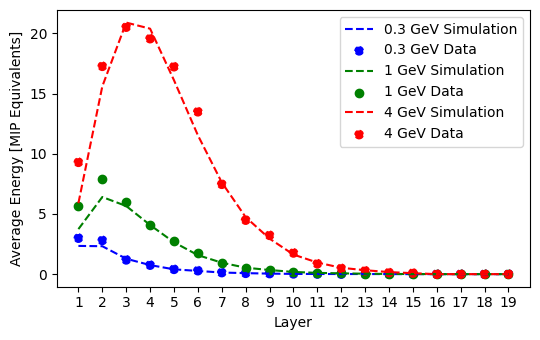

In [500]:
#Longitudinal profile 
fig, ax = plt.subplots(1,1,figsize=(5.5,3.5))

longprofile_0p3GeV_mc = [0.0, 2.3458541223609863, 2.320868165477111, 1.281022342599033, 0.752910203080874, 0.39947160176141855, 0.26789762968143754, 0.13295402760028424, 0.08357890635651583, 0.04355370064337768, 0.02020292700593498, 0.013690519078053328, 0.009080173141068171, 0.0090864814485191, 0.003418898651926544, 0.002248022938646746, 0.0, 0.0, 0.0, 0.0]
longprofile_0p3GeV_data = [0.0, 2.994726693069599, 2.80678823303896, 1.188727629870919, 0.7533707642017337, 0.4053087615806557, 0.2911055326280567, 0.1324989528095049, 0.07486538200296108, 0.05100256267259164, 0.028313674823790047, 0.015248576130763615, 0.006999665661899425, 0.004222675082369656, 0.003121396834348823, 0.0018357224293855698, 0.0, 0.0, 0.0, 0.0]

plt.plot([i for i in range(1,20)], longprofile_0p3GeV_mc[1:],color="blue", linestyle="--", label="0.3 GeV Simulation")
plt.scatter([i for i in range(1,20)], longprofile_0p3GeV_data[1:],color="blue", linestyle="--",label="0.3 GeV Data")

longprofile_1GeV_mc = [0.0, 3.7414196602861356, 6.408858067940817, 5.663222193290354, 4.0830820026968375, 2.6470550729822526, 1.5811996262329846, 0.9501864929715973, 0.536252826972399, 0.342491036411654, 0.18217674802052547, 0.10680776394083487, 0.06537551190646693, 0.03556481769953938, 0.014698491861142516, 0.010403244559779638, 0.0, 0.0, 0.0, 0.0]
longprofile_1GeV_data = [0.0, 5.6953944354624575, 7.9154175081144045, 5.977126328764519, 4.092487607672627, 2.7835558298661773, 1.7855684250557426, 0.9229196165597621, 0.5017027240361278, 0.32527523124208585, 0.20336007697733116, 0.0809760421530079, 0.06361027415184443, 0.032646879310352414, 0.015348266809051825, 0.013466258445779639, 0.0, 0.0, 0.0, 0.0]

plt.plot([i for i in range(1,20)], longprofile_1GeV_mc[1:], color="green", linestyle="--", label="1 GeV Simulation")
plt.scatter([i for i in range(1,20)], longprofile_1GeV_data[1:], color="green", label="1 GeV Data")

longprofile_4GeV_mc = [0.0, 5.898400872172526, 15.600767038903166, 20.90468078908871, 20.3993616385739, 16.11441108914029, 11.53848201874843, 7.62288327285771, 4.736334974134582, 2.950498918189673, 1.6271843114224376, 0.962614392911584, 0.5297374586241631, 0.32548055217397925, 0.17231119126102154, 0.08054024856817375, 0.0, 0.0, 0.0, 0.0]
longprofile_4GeV_data = [0.0, 9.29895126794804, 17.275803995269783, 20.529138091620847, 19.57172082628268, 17.240352016095034, 13.497675548611511, 7.472256892032105, 4.492023508856683, 3.2298467828940383, 1.7652711398901826, 0.8667052963684406, 0.4847334061368423, 0.2819776316605865, 0.13320709238138756, 0.09634227186359105, 0.0, 0.0, 0.0, 0.0]

plt.plot([i for i in range(1,20)], longprofile_4GeV_mc[1:], color="red", linestyle="--", label="4 GeV Simulation")
plt.scatter([i for i in range(1,20)], longprofile_4GeV_data[1:], color="red", linestyle="--", label="4 GeV Data")
plt.xticks([i for i in range(1,20)])

ax.set_ylabel("Average Energy [MIP Equivalents]")
ax.set_xlabel("Layer")

ax.legend()
plt.tight_layout()
plt.savefig("plots/datamccomparisons/longitudinal_combined.pdf")
plt.show()

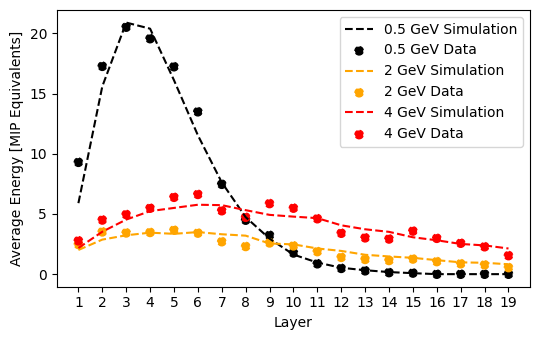

In [5]:
#Longitudinal profile 
fig, ax = plt.subplots(1,1,figsize=(5.5,3.5))

longprofile_pion_0p5GeV_mc = [0.0, 5.898400872172526, 15.600767038903166, 20.90468078908871, 20.3993616385739, 16.11441108914029, 11.53848201874843, 7.62288327285771, 4.736334974134582, 2.950498918189673, 1.6271843114224376, 0.962614392911584, 0.5297374586241631, 0.32548055217397925, 0.17231119126102154, 0.08054024856817375, 0.0, 0.0, 0.0, 0.0]
longprofile_pion_0p5GeV_data = [0.0, 9.29895126794804, 17.275803995269783, 20.529138091620847, 19.57172082628268, 17.240352016095034, 13.497675548611511, 7.472256892032105, 4.492023508856683, 3.2298467828940383, 1.7652711398901826, 0.8667052963684406, 0.4847334061368423, 0.2819776316605865, 0.13320709238138756, 0.09634227186359105, 0.0, 0.0, 0.0, 0.0]

plt.plot([i for i in range(1,20)], longprofile_pion_0p5GeV_mc[1:], color="black", linestyle="--", label="0.5 GeV Simulation")
plt.scatter([i for i in range(1,20)], longprofile_pion_0p5GeV_data[1:], color="black", linestyle="--", label="0.5 GeV Data")

longprofile_pion_1GeV_mc = [0.0, 1.8680133500911718, 2.4133154601129867, 2.3668977293172357, 2.4187791073224165, 2.1645195414801592, 2.1283084090723103, 1.9091850494911233, 1.6086000673709675, 1.2976236339503746, 1.2027067176816866, 0.9511172563090616, 0.901593247981209, 0.7203160965143831, 0.6552864211950759, 0.5716903422274435, 0.4384418566283976, 0.35612574161153226, 0.28433344542883093, 0.22916187064723334]
longprofile_pion_1GeV_data = [0.0, 1.946420688219418, 2.48493749813221, 2.1504056205836957, 1.9795055568842546, 1.9213752944468643, 1.755438970020695, 1.3679460624196578, 1.1610030266995592, 1.168332393614103, 1.0238481368919758, 0.8591066714367448, 0.6783832364382177, 0.6075584425651571, 0.5570206501073994, 0.5514678447676432, 0.4710520339095258, 0.39444210348854003, 0.34924679871622843, 0.28249787010508]

#plt.plot([i for i in range(1,20)], longprofile_pion_1GeV_mc[1:], color="green", linestyle="--", label="1 GeV Simulation")
#plt.scatter([i for i in range(1,20)], longprofile_pion_1GeV_data[1:], color="green", linestyle="--", label="1 GeV Data")

longprofile_pion_2GeV_mc = [0.0, 2.0084850821762914, 2.870124070215876, 3.228234248319364, 3.447414237968314, 3.3498571985389147, 3.4959499835909873, 3.3142440005980744, 3.198032698786223, 2.5475078553428006, 2.4739935741109194, 2.1338909154967247, 1.9293072755156044, 1.6092059573644724, 1.4701679630206688, 1.3548813526459587, 1.1620514470216496, 0.9794016777350574, 0.9439915944708805, 0.8197201786386435]
longprofile_pion_2GeV_data = [0.0, 2.4722290503910367, 3.516219743360864, 3.4314580563394186, 3.471498472850596, 3.6578077149946506, 3.416902068713772, 2.7012525780006866, 2.3042521747930524, 2.6014054618717535, 2.3533583551536372, 1.8778785870994223, 1.4009686939337709, 1.2302966425348976, 1.1396022281141134, 1.263165795376664, 1.047315745708922, 0.8701913020939391, 0.7763859229570327, 0.5479973364858646]

plt.plot([i for i in range(1,20)], longprofile_pion_2GeV_mc[1:], color="orange", linestyle="--", label="2 GeV Simulation")
plt.scatter([i for i in range(1,20)], longprofile_pion_2GeV_data[1:], color="orange", linestyle="--", label="2 GeV Data")

longprofile_pion_3GeV_mc = [0.0, 2.1882034452177868, 3.455692241871067, 4.175910929076178, 4.65742590553367, 4.796883455392537, 4.47635946734406, 4.635558097837132, 4.128685890962376, 3.7488750106502815, 3.44624379921965, 3.3036111614744303, 2.892740654755277, 2.5345147531393084, 2.5152564261790586, 2.211001315298317, 2.0508538949973487, 1.7840642690756054, 1.6180821997748964, 1.3501485142530683]
longprofile_pion_3GeV_data = [0.0, 3.2652609833539183, 5.113916655891686, 5.338439273104043, 5.489111033827486, 5.745822417707967, 5.425851652525425, 4.095543845224301, 3.500411208473143, 4.024901204764336, 3.697279114620607, 3.025805662126462, 2.252344900501419, 1.9910396371535417, 1.8782312568072985, 2.2154935793013704, 1.8250393426524087, 1.5827728408036787, 1.4182628928478338, 0.9535849996631836]

#plt.plot([i for i in range(1,20)], longprofile_pion_3GeV_mc[1:], color="purple", linestyle="--", label="3 GeV Simulation")
#plt.scatter([i for i in range(1,20)], longprofile_pion_3GeV_data[1:], color="purple", linestyle="--", label="3 GeV Data")

longprofile_pion_4GeV_mc = [0.0, 2.172183629502594, 3.5250523778255305, 4.533999617989166, 5.237890571782375, 5.501893977371933, 5.7673108321589694, 5.733147362542831, 5.315877551894035, 4.926275369031681, 4.7797925949828, 4.654789815670735, 4.05865718126089, 3.728698685590945, 3.514273504503554, 3.0637394796299176, 2.813817446296135, 2.5093523797763537, 2.3887584302292457, 2.130586381933297]
longprofile_pion_4GeV_data = [0.0, 2.773547707745884, 4.5044352956740665, 4.959849005857135, 5.485239230325767, 6.3926282138917845, 6.631925481066061, 5.274872949560823, 4.731370994394551, 5.869489455146337, 5.490420257532853, 4.609807713163377, 3.4044327460200163, 3.0222709743456035, 2.9278339685112176, 3.5862401465228197, 2.9833889512833345, 2.5755092889276043, 2.2817915322631483, 1.5428650310479335]

plt.plot([i for i in range(1,20)], longprofile_pion_4GeV_mc[1:], color="red", linestyle="--", label="4 GeV Simulation")
plt.scatter([i for i in range(1,20)], longprofile_pion_4GeV_data[1:], color="red", linestyle="--", label="4 GeV Data")

plt.xticks([i for i in range(1,20)])

ax.set_ylabel("Average Energy [MIP Equivalents]")
ax.set_xlabel("Layer")

ax.legend()
plt.tight_layout()
plt.savefig("plots/datamccomparisons/longitudinal_pion_combined.pdf")
plt.show()